# BMW Pricing - Preparación de Datos y Análisis Exploratorio

---

## Información del Proyecto

- **Curso:** DSC-NUCLIO - E01 Preparación de Datos
- **Profesor:** Alberto Vacas
- **Proyecto:** Análisis de Precios BMW
- **Grupo:** 03 - Caballero, Calcerano, Santini
- **Fecha:** Diciembre 2025

---

## Objetivo del Proyecto

Preparar y analizar un dataset de vehículos BMW usados para modelado predictivo de precios. Este notebook realiza:
1. **Limpieza y Preparación de Datos**: Tratamiento de nulos, outliers, duplicados, ingeniería de variables
2. **Análisis Exploratorio de Datos**: Análisis univariable, correlación y bivariable
3. **Transformación de Variables**: Codificación de categóricas y escalado numérico
4. **Documentación**: Justificaciones detalladas de todas las decisiones de preprocesamiento

**Resultado Final:** Dataset limpio y preprocesado con 0 valores nulos y registros numéricos en su totalidad.

---


## PARTE 0: CONFIGURACIÓN INICIAL Y ANÁLISIS EXPLORATORIO DE DATOS


### 0.1. Configuración del Entorno y Carga de Datos

In [372]:
# IMPORTAMOS LIBRERÍAS NECESARIAS PARA EL ANÁLISIS
# pandas: para manipulación de datos
# numpy: para operaciones numéricas
# matplotlib y seaborn: para visualizaciones
# sklearn: para preprocesamiento de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# Configuramos el estilo de las visualizaciones
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


### 0.2. Visión General del Dataset Inicial

In [373]:
# LEEMOS EL FICHERO DE BMW PRICING

df_bmw = pd.read_csv("bmw_pricing.csv", sep=",")
df_bmw.head()


,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01


In [ ]:
#¿Cuál es el tamaño del conjunto de datos?
df_bmw.shape

(4843, 18)

In [ ]:
#¿Qué tipo de datos tengo?
df_bmw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

In [ ]:
#¿Cuál es la distribución de las variables?
df_bmw.describe()

,km,potencia,precio
count,4.841000e+03,4842.000000,4837.000000
mean,1.409593e+05,128.981826,15831.920612
std,6.020853e+04,38.994839,9222.630708
min,-6.400000e+01,0.000000,100.000000
25%,1.028840e+05,100.000000,10800.000000
50%,1.410800e+05,120.000000,14200.000000
75%,1.752170e+05,135.000000,18600.000000
max,1.000376e+06,423.000000,178500.000000


In [452]:
#Vemos valores únicos de las variables
df_bmw.nunique()

marca                             1
modelo                           76
km                             4784
potencia                         61
fecha_registro                  180
tipo_gasolina                     5
color                            10
tipo_coche                        8
volante_regulable                 2
aire_acondicionado                2
camara_trasera                    2
asientos_traseros_plegables       2
elevalunas_electrico              2
bluetooth                         2
gps                               2
alerta_lim_velocidad              2
precio                          437
fecha_venta                      13
dtype: int64

In [450]:
#¿Existen valores repetidos?
df_bmw.duplicated().sum()

np.int64(0)

In [451]:
#¿Existen valores vacíos?
df_bmw.isnull().sum()

marca                           970
modelo                            3
km                                2
potencia                          1
fecha_registro                 2423
tipo_gasolina                     5
color                           445
tipo_coche                     1460
volante_regulable                 4
aire_acondicionado              486
camara_trasera                    2
asientos_traseros_plegables    3391
elevalunas_electrico              2
bluetooth                       728
gps                               0
alerta_lim_velocidad            728
precio                            6
fecha_venta                       1
dtype: int64

---

## PARTE 1: LIMPIEZA Y PREPARACIÓN DE DATOS

> **Objetivo:** Limpiar el dataset original tratando nulos, outliers, duplicados y creando nuevas variables


### 1.0. Normalización Inicial de Datos

**Problema detectado:** Las variables categóricas presentan inconsistencias de formato (mayúsculas/minúsculas, espacios).

**Ejemplo:** `tipo_gasolina` tiene valores 'diesel' (4,631 registros) y 'Diesel' (5 registros) que son el mismo tipo.

**Solución:** Normalizamos todas las variables categóricas a minúsculas y eliminamos espacios extra para garantizar consistencia.

In [374]:
# Creamos una copia del dataset para trabajar
df_bmw_clean = df_bmw.copy()

# Normalización de variables categóricas: convertir a minúsculas y eliminar espacios
# Esto garantiza consistencia en valores como 'diesel' vs 'Diesel'

variables_categoricas = ['modelo', 'tipo_gasolina', 'color', 'tipo_coche']

for col in variables_categoricas:
    if col in df_bmw_clean.columns:
        # Guardamos valores únicos antes
        valores_antes = df_bmw_clean[col].nunique()
        
        # Convertir a string, minúsculas y eliminar espacios
        df_bmw_clean[col] = df_bmw_clean[col].astype(str).str.lower().str.strip()
        
        # Reemplazar 'nan' strings por NaN reales
        df_bmw_clean[col] = df_bmw_clean[col].replace('nan', pd.NA)
        
        # Valores únicos después
        valores_despues = df_bmw_clean[col].nunique()
        
        print(f"\n{col}:")
        print(f"  Valores únicos antes:  {valores_antes}")
        print(f"  Valores únicos después: {valores_despues}")
        if valores_antes != valores_despues:
            print(f"Normalización aplicada ({valores_antes - valores_despues} duplicados eliminados)")



modelo:
  Valores únicos antes:  76
  Valores únicos después: 76

tipo_gasolina:
  Valores únicos antes:  5
  Valores únicos después: 4
Normalización aplicada (1 duplicados eliminados)

color:
  Valores únicos antes:  10
  Valores únicos después: 10

tipo_coche:
  Valores únicos antes:  8
  Valores únicos después: 8


**Nota técnica sobre `pd.NA`:**

`pd.NA` es el valor nulo experimental de pandas (introducido en pandas 1.0.0). Representa un valor faltante de forma agnóstica al tipo de dato.

**Diferencias clave:**
- `None`: Valor nulo de Python, pero puede causar problemas de tipo
- `np.nan`: Valor nulo de NumPy, pero solo funciona bien con floats
- `pd.NA`: Valor nulo moderno de pandas, funciona consistentemente con cualquier tipo de dato (strings, integers, booleans, etc.)

**Ventaja en nuestro caso:** Al normalizar strings categóricos, `pd.NA` se propaga correctamente sin convertir la columna a float (como haría `np.nan`) ni causar errores de tipo (como podría hacer `None`).


### 1.1. Evaluación de los Datos y Modificaciones


**Evaluación de Valores Nulos:**


In [ ]:
# En el EDA vimos que tenemos nulos en algunas columnas. Vamos a evaluar cuáles son los más críticos.
# Calculamos el porcentaje de nulos por columna y lo ordenamos para empezar a tratarlos.

porcentaje_nulos = (df_bmw.isnull().sum() / len(df_bmw)) * 100
porcentaje_nulos = porcentaje_nulos.sort_values(ascending=False)
porcentaje_nulos


asientos_traseros_plegables    70.018584
fecha_registro                 50.030973
tipo_coche                     30.146603
marca                          20.028908
alerta_lim_velocidad           15.032005
bluetooth                      15.032005
aire_acondicionado             10.035102
color                           9.188520
precio                          0.123890
tipo_gasolina                   0.103242
volante_regulable               0.082593
modelo                          0.061945
camara_trasera                  0.041297
elevalunas_electrico            0.041297
km                              0.041297
potencia                        0.020648
fecha_venta                     0.020648
gps                             0.000000
dtype: float64

### 1.2. Eliminación de Columnas

**Acción:** Eliminamos 2 columnas con problemas de calidad de datos.

**Columnas eliminadas:**
1. **`marca`** -> 970 nulos (20%), todos los valores no nulos son 'BMW'
2. **`asientos_traseros_plegables`** -> 3,391 nulos (70%, demasiado alto para imputación confiable)

**Justificación breve:** Variables sin varianza o con >70% de nulos no aportan valor predictivo.


In [379]:
# Analizamos la columna 'marca'. Si todos los valores son BMW o nulos, no aporta información
# La mayoría de los registros deberían ser BMW, pero hay algunos nulos
df_bmw['marca'].value_counts(dropna=False)


marca
BMW    3873
NaN     970
Name: count, dtype: int64

In [380]:
# Analizamos 'asientos_traseros_plegables' que tiene más del 70% de nulos
# Esta columna tiene demasiados valores faltantes para ser útil
df_bmw['asientos_traseros_plegables'].value_counts(dropna=False)


asientos_traseros_plegables
NaN      3391
False    1150
True      302
Name: count, dtype: int64

In [381]:
# DECISIÓN: Eliminamos columnas que no aportan valor:
# 1. 'marca': Todos los coches son BMW (o deberían serlo), no aporta información discriminativa
# 2. 'asientos_traseros_plegables': Tiene más del 70% de nulos, no es útil para el modelo

columnas_eliminar = ['marca', 'asientos_traseros_plegables']
df_bmw_clean = df_bmw_clean.drop(columns=columnas_eliminar)
df_bmw_clean.shape


(4843, 16)

### 1.3. Corrección de Tipos de Datos


In [382]:
# Convertimos las columnas de fecha a formato datetime

df_bmw_clean['fecha_registro'] = pd.to_datetime(df_bmw_clean['fecha_registro'], errors='coerce')
df_bmw_clean['fecha_venta'] = pd.to_datetime(df_bmw_clean['fecha_venta'], errors='coerce')

# Verificamos la conversión
df_bmw_clean[['fecha_registro', 'fecha_venta']].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   fecha_registro  2420 non-null   datetime64[ns]
 1   fecha_venta     4842 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 75.8 KB


In [383]:
# Vemos que valores son nulos en las columnas de fecha después de la conversión

print(df_bmw_clean['fecha_registro'].isna().sum())
print(df_bmw_clean['fecha_venta'].isna().sum())

2423
1


### 1.4. Eliminación de Duplicados


In [384]:
# Identificamos registros duplicados

duplicados = df_bmw_clean.duplicated()
duplicados.sum()

np.int64(0)

In [385]:
# En el caso de tener duplicados (no es nuestro caso) los eliminaríamos y resetearíamos el índice
df_bmw_clean = df_bmw_clean.drop_duplicates().reset_index(drop=True)

# Luego podríamos calcular el número de registros eliminados
df_bmw.shape[0] - df_bmw_clean.shape[0]


0

### 1.5. Ingeniería de Variables

**Nuevas variables creadas:**
- **`EDAD_VEHICULO`** = (fecha_venta - fecha_registro) en años -> Predictor clave para depreciación
- **`fecha_registro_disponible`** = (True=original, False=imputado por nosotros)


In [386]:
# Creamos una variable que puede ser útil para el modelo:
# 1. EDAD_VEHICULO: años desde el registro hasta la venta

# IMPORTANTE: Hacemos todos los cálculos en DÍAS para mayor precisión
# Esto evita errores de redondeo al convertir años→días→años

# Calculamos primero la edad en DÍAS
df_bmw_clean['EDAD_VEHICULO_DIAS'] = (df_bmw_clean['fecha_venta'] - df_bmw_clean['fecha_registro']).dt.days

# Convertimos a años (usamos 365.25 para considerar años bisiestos)
df_bmw_clean['EDAD_VEHICULO'] = df_bmw_clean['EDAD_VEHICULO_DIAS'] / 365.25

In [387]:
# LIMPIEZA 1: Eliminamos SOLO registros con edad negativa (error en los datos originales)
# Esto ocurre cuando fecha_registro > fecha_venta, lo cual no tiene sentido
# IMPORTANTE: Preservamos los NaN (fecha_registro nulos) para imputarlos después
print(f"Registros con EDAD_VEHICULO negativa: {(df_bmw_clean['EDAD_VEHICULO'] < 0).sum()}")
registros_antes = len(df_bmw_clean)
# Usamos ~(< 0) en lugar de >= 0 para preservar NaN
df_bmw_clean = df_bmw_clean[~(df_bmw_clean['EDAD_VEHICULO'] < 0)].copy()
registros_despues = len(df_bmw_clean)
print(f"Registros eliminados (solo negativos): {registros_antes - registros_despues}")
print(f"Registros restantes: {registros_despues}")
print(f"Registros con EDAD_VEHICULO nulos (para imputar): {df_bmw_clean['EDAD_VEHICULO'].isna().sum()}")

Registros con EDAD_VEHICULO negativa: 2
Registros eliminados (solo negativos): 2
Registros restantes: 4841
Registros con EDAD_VEHICULO nulos (para imputar): 2423


In [388]:
# LIMPIEZA 2: Eliminamos registros con potencia = 0 o NaN (errores en datos)
# Un vehículo necesita potencia para funcionar, potencia = 0 es un error evidente
# NOTA: El filtro 'potencia > 0' elimina TANTO valores = 0 COMO valores NaN
print(f"\nRegistros con potencia = 0: {(df_bmw_clean['potencia'] == 0).sum()}")
print(f"Registros con potencia NaN: {df_bmw_clean['potencia'].isna().sum()}")
registros_antes_potencia = len(df_bmw_clean)
df_bmw_clean = df_bmw_clean[df_bmw_clean['potencia'] > 0].copy()
registros_despues_potencia = len(df_bmw_clean)
print(f"Registros eliminados (potencia = 0 o NaN): {registros_antes_potencia - registros_despues_potencia}")
print(f"Registros restantes: {registros_despues_potencia}")


Registros con potencia = 0: 1
Registros con potencia NaN: 1
Registros eliminados (potencia = 0 o NaN): 2
Registros restantes: 4839


In [389]:
# LIMPIEZA 3: Eliminamos registros con km negativos, cero o NaN (errores en datos)
# Kilómetros negativos o cero son físicamente imposibles (un vehículo usado debe tener km > 0)
# NOTA: El filtro 'km > 0' elimina valores negativos, = 0 Y valores NaN
print(f"\nRegistros con km <= 0: {(df_bmw_clean['km'] <= 0).sum()}")
print(f"Registros con km NaN: {df_bmw_clean['km'].isna().sum()}")
registros_antes_km = len(df_bmw_clean)
df_bmw_clean = df_bmw_clean[df_bmw_clean['km'] > 0].copy()
registros_despues_km = len(df_bmw_clean)
print(f"Registros eliminados (km <= 0 o NaN): {registros_antes_km - registros_despues_km}")
print(f"Registros restantes: {registros_despues_km}")


Registros con km <= 0: 1
Registros con km NaN: 2
Registros eliminados (km <= 0 o NaN): 3
Registros restantes: 4836


In [390]:
# Verificamos la nueva variable
df_bmw_clean['EDAD_VEHICULO'].describe()

count    2415.000000
mean        5.394610
std         2.514935
min         0.588638
25%         4.076660
50%         4.837782
75%         5.831622
max        28.084873
Name: EDAD_VEHICULO, dtype: float64

### 1.6. Tratamiento de Valores Faltantes

**Estrategia:** Aplicar diferentes técnicas de imputación según el tipo de variable y porcentaje de nulos.


In [391]:
# Revisamos nuevamente los nulos después de las transformaciones iniciales

nulos_actualizados = df_bmw_clean.isnull().sum()
nulos_actualizados = nulos_actualizados[nulos_actualizados > 0].sort_values(ascending=False)
nulos_actualizados


fecha_registro          2421
EDAD_VEHICULO_DIAS      2421
EDAD_VEHICULO           2421
tipo_coche              1458
bluetooth                728
alerta_lim_velocidad     726
aire_acondicionado       485
color                    445
precio                     6
tipo_gasolina              5
volante_regulable          4
modelo                     3
camara_trasera             2
elevalunas_electrico       2
fecha_venta                1
dtype: int64

**Estrategia para nulos por columna:**

1. **precio (target)**: Eliminaremos registros con precio nulo ya que no podemos predecir sin target
2. **modelo/km/potencia**: Son variables numéricas críticas. Tienen pocos nulos. Tiene sentido eliminar o imputar con mediana/moda según corresponda
3. **fecha_registro_disponible**: Tiene sentido crear variable binaria "fecha_registro_disponible", dado que "fecha_registro" tiene un 50% de nulos.
4. **tipo_gasolina**: Imputaremos con moda (valor más frecuente)
5. **tipo_coche**: Tiene aprox 30% nulos. Tiene sentido imputar con moda o crear categoría "desconocido"
6. **color**: Tiene aprox 9% nulos. Tiene sentido imputar con moda o crear categoría "desconocido"
7. **VARIABLES BOOLEANAS**: bluetooth, alerta_lim_velocidad, aire_acondicionado, volante_regulable, camara_trasera, elevalunas_electrico. Estas variables tienen valores True/False/NaN. Tratamos NaN como False (ausencia de característica)
8. **gps**: Ya es booleano, verificamos que no tenga nulos
9. **fecha_venta**: Eliminamos si falta (es crítica y solo hay un valor nulo)
10. **fecha_registro**: Tiene aprox 50% nulos. Hay que pensar en una estrategia inteligente ya que
no podemos imputar media al 50% de los datos, ni eliminar el 50% de los registros. Además, la consideramos una variable relevante para la predicción, por lo que no queremos eliminarla.




In [392]:
# 1. precio (target): Eliminamos registros sin precio
# No podemos usar registros sin precio para entrenar el modelo

print(f"Registros antes de eliminar nulos en precio: {len(df_bmw_clean)}")
df_bmw_clean = df_bmw_clean.dropna(subset=['precio'])
print(f"Registros despues: {len(df_bmw_clean)}")
print(f"Registros eliminados: {df_bmw.shape[0] - len(df_bmw_clean)}")


Registros antes de eliminar nulos en precio: 4836
Registros despues: 4830
Registros eliminados: 13


In [393]:
# 2. modelo, km, potencia
# Estas son variables importantes, eliminamos registros si faltan valores críticos

print("Nulos en variables numéricas críticas:")
print(f"modelo: {df_bmw_clean['modelo'].isnull().sum()}")
print(f"km: {df_bmw_clean['km'].isnull().sum()}")
print(f"potencia: {df_bmw_clean['potencia'].isnull().sum()}")

# Eliminamos registros sin modelo, km o potencia ya que són pocas
df_bmw_clean = df_bmw_clean.dropna(subset=['modelo', 'km', 'potencia'])
print(f"Registros después de eliminar nulos en variables críticas: {len(df_bmw_clean)}")


Nulos en variables numéricas críticas:
modelo: 3
km: 0
potencia: 0
Registros después de eliminar nulos en variables críticas: 4827


In [394]:
# 3. fecha_registro: Crear variable binaria y mantener nulos
# Como tiene muchos nulos (aprox 50%), creamos una variable indicadora
# Para EDAD_VEHICULO, los nulos se mantienen (serán NaN) y los trataremos después

df_bmw_clean['fecha_registro_disponible'] = df_bmw_clean['fecha_registro'].notna().astype(bool)
df_bmw_clean['fecha_registro_disponible'].value_counts(dropna=False)

fecha_registro_disponible
False    2414
True     2413
Name: count, dtype: int64

In [395]:
# 4. tipo_gasolina: Imputamos con moda (valor más frecuente)
# Es una variable categórica importante

moda_tipo_gasolina = df_bmw_clean['tipo_gasolina'].mode()[0]
print(f"Moda de tipo_gasolina: {moda_tipo_gasolina}")
print(f"Nulos antes: {df_bmw_clean['tipo_gasolina'].isnull().sum()}")

df_bmw_clean['tipo_gasolina'] = df_bmw_clean['tipo_gasolina'].fillna(moda_tipo_gasolina)
print(f"Nulos despues: {df_bmw_clean['tipo_gasolina'].isnull().sum()}")


Moda de tipo_gasolina: diesel
Nulos antes: 5
Nulos despues: 0


In [396]:
# 5. tipo_coche: Imputar con moda o crear categoría "desconocido"
# Tiene aprox 30% de nulos, pero es una variable importante, 
# por lo que deicidimos crear categoría "desconocido" en lugar de imputar con moda

print(df_bmw_clean['tipo_coche'].value_counts(dropna=False))
df_bmw_clean['tipo_coche'] = df_bmw_clean['tipo_coche'].fillna('desconocido')

print(df_bmw_clean['tipo_coche'].value_counts(dropna=False))


tipo_coche
<NA>           1454
estate         1102
sedan           820
suv             753
hatchback       488
subcompact       77
coupe            75
convertible      30
van              28
Name: count, dtype: int64
tipo_coche
desconocido    1454
estate         1102
sedan           820
suv             753
hatchback       488
subcompact       77
coupe            75
convertible      30
van              28
Name: count, dtype: int64


In [397]:
# 6. color: Imputar con moda o crear categoría "desconocido"
# Tiene aprox 9% nulos. Tiene sentido imputar con moda o crear categoría "desconocido"
# Decidimos crear categoría desconocido para mantener la información de que falta el dato

print("Color antes de imputar:")
print(df_bmw_clean['color'].value_counts(dropna=False).head(10))
df_bmw_clean['color'] = df_bmw_clean['color'].fillna('desconocido')

print("\n")
print("Color después de imputar:")
print(df_bmw_clean['color'].value_counts(dropna=False).head(10))

Color antes de imputar:
color
black     1492
grey      1069
blue       643
white      482
<NA>       444
brown      302
silver     291
red         47
beige       37
green       14
Name: count, dtype: int64


Color después de imputar:
color
black          1492
grey           1069
blue            643
white           482
desconocido     444
brown           302
silver          291
red              47
beige            37
green            14
Name: count, dtype: int64


In [398]:
# 7. VARIABLES BOOLEANAS: bluetooth, alerta_lim_velocidad, aire_acondicionado, volante_regulable, camara_trasera, elevalunas_electrico
# Estas variables tienen valores True/False/NaN. Tratamos NaN como False (ausencia de característica)

variables_booleanas = ['bluetooth', 'alerta_lim_velocidad', 'aire_acondicionado', 'volante_regulable', 'camara_trasera', 'elevalunas_electrico']

for var in variables_booleanas:
    nulos_antes = df_bmw_clean[var].isnull().sum()
    
    # Convertimos a booleano y rellenamos NaN con False en un solo paso (conversión explícita evita FutureWarning)
    df_bmw_clean[var] = df_bmw_clean[var].fillna(False).astype(bool)
    print(f"{var}: {nulos_antes} nulos imputados como False")


bluetooth: 727 nulos imputados como False
alerta_lim_velocidad: 725 nulos imputados como False
aire_acondicionado: 484 nulos imputados como False
volante_regulable: 4 nulos imputados como False
camara_trasera: 2 nulos imputados como False
elevalunas_electrico: 2 nulos imputados como False


/var/folders/ps/jqlt68cn4jj4sxcmj_4y13zh0000gn/T/ipykernel_43141/2950391778.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bmw_clean[var] = df_bmw_clean[var].fillna(False).astype(bool)
/var/folders/ps/jqlt68cn4jj4sxcmj_4y13zh0000gn/T/ipykernel_43141/2950391778.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bmw_clean[var] = df_bmw_clean[var].fillna(False).astype(bool)
/var/folders/ps/jqlt68cn4jj4sxcmj_4y13zh0000gn/T/ipykernel_43141/2950391778.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated a

In [399]:
# 8. gps: Ya es booleano, verificamos que no tenga nulos
print(df_bmw_clean['gps'].isnull().sum())
print(df_bmw_clean['gps'].dtype)


0
bool


In [400]:
# 9. fecha_venta: Eliminamos si falta (es crítica y solo hay un valor nulo)
df_bmw_clean = df_bmw_clean.dropna(subset=['fecha_venta'])
len(df_bmw_clean)


4826

In [401]:
# Verificamos el estado actual de los nulos
nulos_finales = df_bmw_clean.isnull().sum()

nulos_finales = nulos_finales[nulos_finales > 0]
if len(nulos_finales) > 0:
    print(nulos_finales)
    print ("A seguir con los nulos...")
else:
    print("El grupo 3 lo está petando")

fecha_registro        2413
EDAD_VEHICULO_DIAS    2413
EDAD_VEHICULO         2413
dtype: int64
A seguir con los nulos...


#### 1.6.4. fecha_registro - Imputación Avanzada (50% nulos)

**Estrategia:** Estimar `fecha_registro` usando la relación promedio km/año de registros no nulos.

**Método:**
1. Calcular mediana km/año de registros con fecha_registro válida (26,293 km/año)
2. Estimar EDAD_VEHICULO = km / 26,293 para registros nulos 
3. Convertir a días (x 365.25 para años bisiestos) para mayor precisión
4. Retro-calcular fecha_registro = fecha_venta - edad_dias
5. Recalcular EDAD_VEHICULO desde fecha_registro para garantizar consistencia

**Justificación breve:** 
- 50% de nulos es demasiado alto para eliminar registros
- Usar la relación km/edad preserva la información individual del vehículo mejor que la imputación simple por media/mediana
- **Cálculos en días evitan errores de redondeo** al hacer conversiones múltiples años<->días


In [402]:
# PASO 1: Analizamos los registros CON fecha_registro para calcular km/año promedio

# Filtramos registros con fecha_registro válida
df_con_fecha = df_bmw_clean[df_bmw_clean['fecha_registro'].notna()].copy()

# Calculamos km por año para cada vehículo
# Usamos EDAD_VEHICULO que ya está calculada en años desde días
df_con_fecha['km_por_año'] = df_con_fecha['km'] / df_con_fecha['EDAD_VEHICULO']

df_con_fecha['km_por_año'].describe()


count      2413.000000
mean      27685.896708
std       11454.261779
min         367.652961
25%       19743.388289
50%       26644.743458
75%       34766.671770
max      164551.145604
Name: km_por_año, dtype: float64

In [403]:
# PASO 2: Limpiamos valores atípicos para obtener un promedio de km_por_año más realista

# Eliminamos casos problemáticos:
# EDAD_VEHICULO <= 0 o muy alta (>25 años es poco común en coches usados)
# km_por_año muy bajo (<1000 km/año: coche casi no usado) o muy alto (>50000 km/año: uso extremo)

df_con_fecha_limpio = df_con_fecha[
    (df_con_fecha['EDAD_VEHICULO'] > 0) & 
    (df_con_fecha['EDAD_VEHICULO'] < 25) &
    (df_con_fecha['km_por_año'] > 1000) &
    (df_con_fecha['km_por_año'] < 50000)
].copy()

print(f"Registros eliminados: {len(df_con_fecha) - len(df_con_fecha_limpio)}")

print(df_con_fecha_limpio['km_por_año'].describe())

Registros eliminados: 65
count     2348.000000
mean     26872.376216
std      10069.660946
min       1199.379070
25%      19544.196615
50%      26310.744642
75%      34114.849202
max      49950.375286
Name: km_por_año, dtype: float64


In [404]:
# Calculamos mediana y media
km_por_año_mediana = df_con_fecha_limpio['km_por_año'].median()
km_por_año_media = df_con_fecha_limpio['km_por_año'].mean()

print(f"Mediana: {km_por_año_mediana:.0f} km/año")
print(f"Media: {km_por_año_media:.0f} km/año")

Mediana: 26311 km/año
Media: 26872 km/año


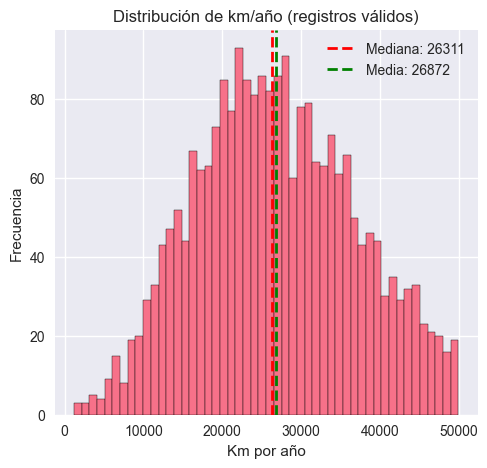

In [405]:
# Visualizamos la distribución de km/año, usaremos la mediana por ser más robusta ante outliers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_con_fecha_limpio['km_por_año'], bins=50, edgecolor='black')
plt.axvline(km_por_año_mediana, color='red', linestyle='--', linewidth=2, label=f'Mediana: {km_por_año_mediana:.0f}')
plt.axvline(km_por_año_media, color='green', linestyle='--', linewidth=2, label=f'Media: {km_por_año_media:.0f}')
plt.xlabel('Km por año')
plt.ylabel('Frecuencia')
plt.title('Distribución de km/año (registros válidos)')
plt.legend()

In [406]:
# PASO 3: Imputamos fecha_registro para los registros SIN fecha

# Identificamos registros sin fecha_registro
df_sin_fecha_mask = df_bmw_clean['fecha_registro'].isna()
n_sin_fecha = df_sin_fecha_mask.sum()

print(f"Registros sin fecha_registro: {n_sin_fecha}")
print(f"Porcentaje: {(n_sin_fecha / len(df_bmw_clean)) * 100:.1f}%")


Registros sin fecha_registro: 2413
Porcentaje: 50.0%


In [407]:
# Para estos registros:
# 1. Estimamos EDAD_VEHICULO = km / km_por_año_mediana
# 2. Calculamos fecha_registro = fecha_venta - EDAD_VEHICULO (en días)

# Calculamos EDAD_VEHICULO estimada (en años)
edad_estimada_años = df_bmw_clean.loc[df_sin_fecha_mask, 'km'] / km_por_año_mediana
print(edad_estimada_años)

1       0.529403
3       4.866263
4       3.690393
6       7.799817
8       4.708571
          ...   
4834    1.816064
4835    6.298073
4837    2.537746
4838    1.510524
4842    7.443347
Name: km, Length: 2413, dtype: float64


In [408]:
# Convertimos edad estimada a DÍAS (más preciso)
edad_estimada_dias = edad_estimada_años * 365.25  # Usamos 365.25 para años bisiestos

# Calculamos fecha_registro: restamos EDAD_VEHICULO (en días) a fecha_venta
# Usamos directamente días para evitar errores de redondeo
df_bmw_clean.loc[df_sin_fecha_mask, 'fecha_registro'] = (
    df_bmw_clean.loc[df_sin_fecha_mask, 'fecha_venta'] - 
    pd.to_timedelta(edad_estimada_dias, unit='days')
)

# IMPORTANTE: Recalculamos EDAD_VEHICULO_DIAS y EDAD_VEHICULO desde fecha_registro imputada
# Esto garantiza consistencia y evita errores de redondeo
df_bmw_clean.loc[df_sin_fecha_mask, 'EDAD_VEHICULO_DIAS'] = (
    (df_bmw_clean.loc[df_sin_fecha_mask, 'fecha_venta'] - 
     df_bmw_clean.loc[df_sin_fecha_mask, 'fecha_registro']).dt.days
)
df_bmw_clean.loc[df_sin_fecha_mask, 'EDAD_VEHICULO'] = (
    df_bmw_clean.loc[df_sin_fecha_mask, 'EDAD_VEHICULO_DIAS'] / 365.25
)

# CORRECCIÓN FINAL: Forzamos que cualquier valor negativo por errores de redondeo sea 0
# Esto garantiza coherencia física (edad no puede ser negativa)
df_bmw_clean['EDAD_VEHICULO'] = df_bmw_clean['EDAD_VEHICULO'].clip(lower=0)


In [409]:
# Eliminamos EDAD_VEHICULO_DIAS: solo fue útil para cálculos intermedios
# Ya tenemos EDAD_VEHICULO (en años) que es lo que realmente necesitamos para el análisis
df_bmw_clean = df_bmw_clean.drop(columns=['EDAD_VEHICULO_DIAS'])
print(f"Variable intermedia 'EDAD_VEHICULO_DIAS' eliminada")
print(f"Columnas restantes en el dataset: {df_bmw_clean.shape[1]}")

Variable intermedia 'EDAD_VEHICULO_DIAS' eliminada
Columnas restantes en el dataset: 18


In [410]:
# Verificación

print(f"Nulos en fecha_registro DESPUÉS: {df_bmw_clean['fecha_registro'].isna().sum()}")
print(f"Nulos en EDAD_VEHICULO DESPUÉS: {df_bmw_clean['EDAD_VEHICULO'].isna().sum()}")
print(df_bmw_clean['EDAD_VEHICULO'].describe())


Nulos en fecha_registro DESPUÉS: 0
Nulos en EDAD_VEHICULO DESPUÉS: 0
count    4826.000000
mean        5.380483
std         2.407545
min         0.016427
25%         4.000000
50%         5.044490
75%         6.255989
max        28.084873
Name: EDAD_VEHICULO, dtype: float64


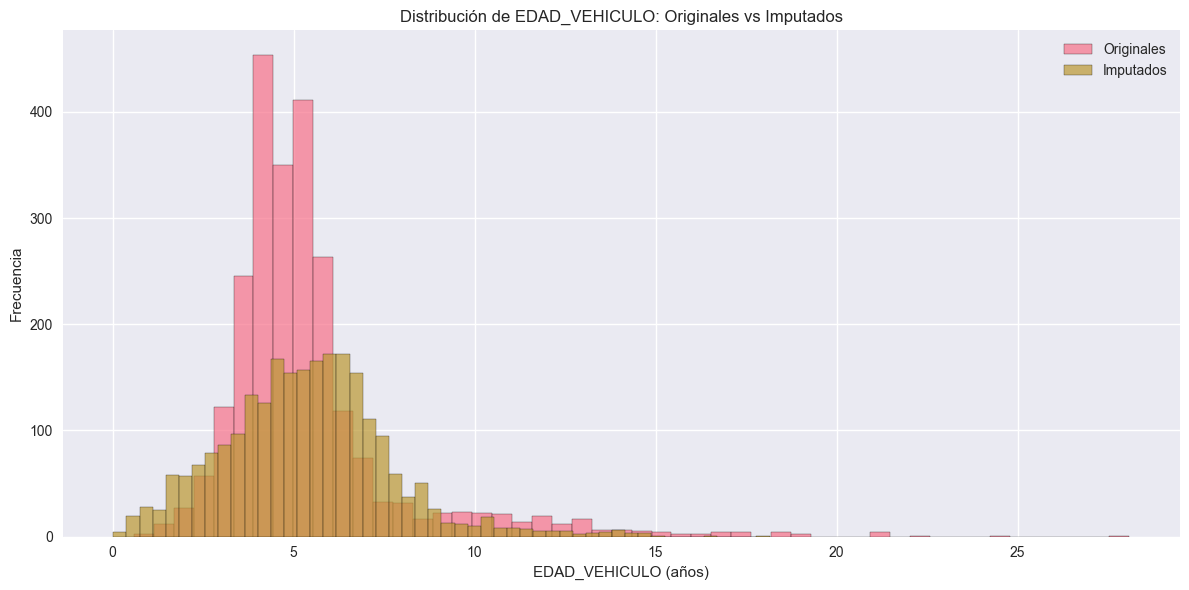

Estadísticas comparativas:
Registros ORIGINALES (con fecha_registro)
count    2413.000000
mean        5.395285
std         2.515867
min         0.588638
25%         4.076660
50%         4.837782
75%         5.831622
max        28.084873
Name: EDAD_VEHICULO, dtype: float64


Registros IMPUTADOS (sin fecha_registro)
count    2413.000000
mean        5.365681
std         2.294542
min         0.016427
25%         3.865845
50%         5.330595
75%         6.650240
max        18.149213
Name: EDAD_VEHICULO, dtype: float64


In [411]:
# PASO 4: Visualizamos el resultado de la imputación

# Comparamos la distribución de EDAD_VEHICULO: originales vs imputados
df_originales = df_bmw_clean[df_bmw_clean['fecha_registro_disponible'] == True]
df_imputados = df_bmw_clean[df_bmw_clean['fecha_registro_disponible'] == False]

# Creamos un único gráfico con ambas distribuciones superpuestas
plt.figure(figsize=(12, 6))
plt.hist(df_originales['EDAD_VEHICULO'], bins=50, alpha=0.7, label='Originales', edgecolor='black')
plt.hist(df_imputados['EDAD_VEHICULO'], bins=50, alpha=0.7, label='Imputados', edgecolor='black')
plt.xlabel('EDAD_VEHICULO (años)')
plt.ylabel('Frecuencia')
plt.title('Distribución de EDAD_VEHICULO: Originales vs Imputados')
plt.legend()
plt.tight_layout()
plt.show()

print("Estadísticas comparativas:")
print("Registros ORIGINALES (con fecha_registro)")
print(df_originales['EDAD_VEHICULO'].describe())
print("\n")
print("Registros IMPUTADOS (sin fecha_registro)")
print(df_imputados['EDAD_VEHICULO'].describe())


In [412]:
# Verificamos el estado final de los nulos (ACTUALIZADO)
nulos_finales = df_bmw_clean.isnull().sum()

nulos_finales = nulos_finales[nulos_finales > 0]
if len(nulos_finales) > 0:
    print(nulos_finales)
    print("A seguir con los nulos...")
else:
    print("NO HAY NULOS EN EL DATASET!")
    print("El grupo 3 lo está petando")


NO HAY NULOS EN EL DATASET!
El grupo 3 lo está petando


In [413]:
df_bmw_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4826 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   modelo                     4826 non-null   object        
 1   km                         4826 non-null   float64       
 2   potencia                   4826 non-null   float64       
 3   fecha_registro             4826 non-null   datetime64[ns]
 4   tipo_gasolina              4826 non-null   object        
 5   color                      4826 non-null   object        
 6   tipo_coche                 4826 non-null   object        
 7   volante_regulable          4826 non-null   bool          
 8   aire_acondicionado         4826 non-null   bool          
 9   camara_trasera             4826 non-null   bool          
 10  elevalunas_electrico       4826 non-null   bool          
 11  bluetooth                  4826 non-null   bool          
 12  gps        

**RESUMEN DE LA IMPUTACIÓN:**

Hemos imputado `fecha_registro` exitosamente usando la estrategia de **km/año promedio**:

1. **Calculamos** el uso promedio (km/año) de vehículos con fecha_registro conocida
2. **Limpiamos** outliers para obtener un promedio realista
3. **Estimamos** EDAD_VEHICULO para nulos: `km / km_por_año_mediana`
4. **Back-calculamos** fecha_registro: `fecha_venta - EDAD_VEHICULO`

**Ventajas de este método:**
- Usa información real del vehículo (km recorridos)
- Mantiene la relación lógica entre variables
- No requiere eliminar el 50% de los registros, ni la variable
- Preserva la variabilidad natural de los datos

La variable `fecha_registro_disponible` se mantiene como indicador de si el valor era original o imputado, lo cual puede ser útil para el modelo.


### 1.7. Análisis de Outliers

**Método:** Método IQR (Rango Intercuartílico) aplicado a `precio` (variable objetivo).

**Decisión:** Mantener 311 outliers superiores (precio > 30,300€, 6.4% del dataset).

**Justificación breve:** Los outliers son modelos BMW de lujo genuinos (M4, M5, X6 M, i8) con alta potencia, no errores de datos. Precios validados contra valores reales de mercado. Eliminarlos eliminaría el segmento premium e introduciría sesgo de selección


count      4826.000000
mean      15827.517613
std        9187.729434
min         100.000000
25%       10825.000000
50%       14200.000000
75%       18600.000000
max      178500.000000
Name: precio, dtype: float64


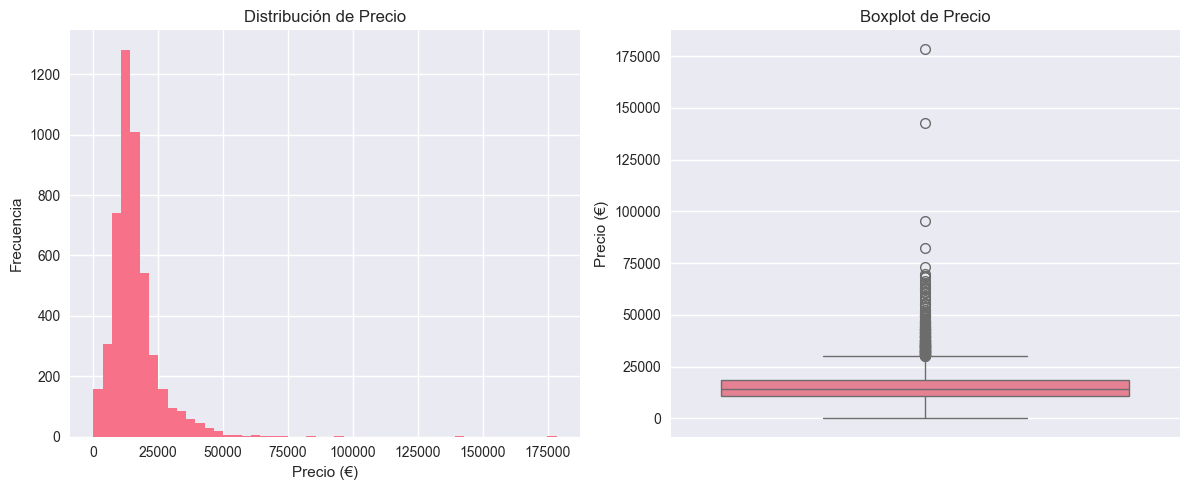

In [414]:
# Analizamos outliers en la variable target (precio)
# Los outliers pueden afectar significativamente el modelo

print(df_bmw_clean['precio'].describe())

# Visualizamos la distribución del precio CON histograma y boxplot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df_bmw_clean['precio'].hist(bins=50)
plt.title('Distribución de Precio')
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_bmw_clean['precio'])
plt.title('Boxplot de Precio')
plt.ylabel('Precio (€)')

plt.tight_layout()
plt.show()


In [415]:
# Identificamos y tratamos outliers en precio usando el método IQR
# Eliminamos precios <= 0 (no tienen sentido) y valores extremos

# Eliminamos precios <= 0 (No tenemos ningun registro con precio <= 0)
# Este sería el proceso a seguir si tuvieramos registros con precio <= 0
print(f"Registros con precio <= 0: {(df_bmw_clean['precio'] <= 0).sum()}")
df_bmw_clean = df_bmw_clean[df_bmw_clean['precio'] > 0]

# Método IQR para outliers superiores
Q1 = df_bmw_clean['precio'].quantile(0.25)
Q3 = df_bmw_clean['precio'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límites IQR:")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")

outliers_inferiores = (df_bmw_clean['precio'] < limite_inferior).sum()
outliers_superiores = (df_bmw_clean['precio'] > limite_superior).sum()

print(f"Outliers inferiores: {outliers_inferiores}")
print(f"Outliers superiores: {outliers_superiores}")

# DECISIÓN: Para precios, los outliers superiores pueden ser válidos (coches de lujo)
# Solo eliminaríamos outliers inferiores (precios anormalmente bajos), que en nuestro caso no existen
df_bmw_clean = df_bmw_clean[df_bmw_clean['precio'] >= limite_inferior]
print(f"\nRegistros después de eliminar outliers inferiores: {len(df_bmw_clean)}")


Registros con precio <= 0: 0
Límites IQR:
Q1: 10825.00, Q3: 18600.00, IQR: 7775.00
Límite inferior: -837.50
Límite superior: 30262.50
Outliers inferiores: 0
Outliers superiores: 312

Registros después de eliminar outliers inferiores: 4826


In [416]:
# Analizamos outliers en otras variables numéricas: km, potencia, EDAD_VEHICULO

variables_numericas = ['km', 'potencia', 'EDAD_VEHICULO']

for var in variables_numericas:
    print(f"\nANÁLISIS DE {var}")
    print(df_bmw_clean[var].describe())
    
    # Eliminamos valores negativos si los hay ya que no tienen sentido
    if (df_bmw_clean[var] < 0).any():
        print(f"Valores negativos encontrados: {(df_bmw_clean[var] < 0).sum()}")
        df_bmw_clean = df_bmw_clean[df_bmw_clean[var] >= 0]
    
    # Para km y potencia, eliminamos valores extremos superiores (pueden ser errores)
    if var in ['km', 'potencia']:
        Q1 = df_bmw_clean[var].quantile(0.25)
        Q3 = df_bmw_clean[var].quantile(0.75)
        IQR = Q3 - Q1
        limite_superior = Q3 + 3 * IQR  # Usamos 3*IQR para ser menos restrictivos
        
        outliers = (df_bmw_clean[var] > limite_superior).sum()
        print(f"Outliers superiores (> Q3 + 3*IQR): {outliers}")
        
        # Solo eliminamos si hay muchos outliers (más del 1%)
        if outliers > len(df_bmw_clean) * 0.01:
            df_bmw_clean = df_bmw_clean[df_bmw_clean[var] <= limite_superior]
            print(f"Eliminados {outliers} outliers")
    
    print(f"Registros restantes: {len(df_bmw_clean)}")



ANÁLISIS DE km
count    4.826000e+03
mean     1.409430e+05
std      6.012787e+04
min      4.760000e+02
25%      1.028630e+05
50%      1.410740e+05
75%      1.752305e+05
max      1.000376e+06
Name: km, dtype: float64
Outliers superiores (> Q3 + 3*IQR): 8
Registros restantes: 4826

ANÁLISIS DE potencia
count    4826.000000
mean      129.010568
std        38.960808
min        25.000000
25%       100.000000
50%       120.000000
75%       135.000000
max       423.000000
Name: potencia, dtype: float64
Outliers superiores (> Q3 + 3*IQR): 47
Registros restantes: 4826

ANÁLISIS DE EDAD_VEHICULO
count    4826.000000
mean        5.380483
std         2.407545
min         0.016427
25%         4.000000
50%         5.044490
75%         6.255989
max        28.084873
Name: EDAD_VEHICULO, dtype: float64
Registros restantes: 4826


In [417]:
for var in variables_numericas:
    print(f"\nANÁLISIS DE {var}")
    print(df_bmw_clean[var].describe())


ANÁLISIS DE km
count    4.826000e+03
mean     1.409430e+05
std      6.012787e+04
min      4.760000e+02
25%      1.028630e+05
50%      1.410740e+05
75%      1.752305e+05
max      1.000376e+06
Name: km, dtype: float64

ANÁLISIS DE potencia
count    4826.000000
mean      129.010568
std        38.960808
min        25.000000
25%       100.000000
50%       120.000000
75%       135.000000
max       423.000000
Name: potencia, dtype: float64

ANÁLISIS DE EDAD_VEHICULO
count    4826.000000
mean        5.380483
std         2.407545
min         0.016427
25%         4.000000
50%         5.044490
75%         6.255989
max        28.084873
Name: EDAD_VEHICULO, dtype: float64


### 1.8. Guardar Dataset Limpio

**Checkpoint:** Dataset limpio listo para análisis exploratorio de datos (EDA).


In [418]:
# Guardamos el dataset limpio en formato pickle para uso posterior
df_bmw_clean.to_pickle("df_bmw_clean.pkl")

# Visualizamos los registros totales eliminados
print(f"Dataset guardado. Dimensiones finales: {df_bmw_clean.shape}")
print(f"Registros originales: {df_bmw.shape[0]}")
print(f"Registros finales: {df_bmw_clean.shape[0]}")
print(f"Registros eliminados: {df_bmw.shape[0] - df_bmw_clean.shape[0]}")


Dataset guardado. Dimensiones finales: (4826, 18)
Registros originales: 4843
Registros finales: 4826
Registros eliminados: 17


---

## PARTE 2: ANÁLISIS UNIVARIABLE + TARGET

> **Objetivo:** Comprender las distribuciones de datos, correlaciones y relaciones con la variable target


### 2.1. Cargar Dataset Limpio


In [437]:
# Leemos el dataset limpio
df_bmw_clean = pd.read_pickle("df_bmw_clean.pkl")
df_bmw_clean.head()


,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,EDAD_VEHICULO,fecha_registro_disponible
0,118,140411.0,100.0,2012-02-01 00:00:00.000000000,diesel,black,desconocido,True,True,False,True,False,True,False,11300.0,2018-01-01,5.916496,True
1,m4,13929.0,317.0,2017-07-22 15:14:56.469719357,petrol,grey,convertible,True,True,False,False,True,True,True,69700.0,2018-02-01,0.528405,False
2,320,183297.0,120.0,2012-04-01 00:00:00.000000000,diesel,white,desconocido,False,False,False,True,False,True,False,10200.0,2018-02-01,5.837098,True
3,420,128035.0,135.0,2013-03-21 14:20:22.535754084,diesel,red,convertible,True,True,False,True,True,True,False,25100.0,2018-02-01,4.865161,False
4,425,97097.0,160.0,2014-07-23 02:00:39.293584658,diesel,silver,desconocido,True,True,False,False,True,True,True,33400.0,2018-04-01,3.687885,False


### 2.2. Análisis Univariable

**Objetivo:** Analizar cada variable individualmente para comprender distribuciones e identificar patrones interesantes.



ANÁLISIS DE KM
count    4.826000e+03
mean     1.409430e+05
std      6.012787e+04
min      4.760000e+02
25%      1.028630e+05
50%      1.410740e+05
75%      1.752305e+05
max      1.000376e+06
Name: km, dtype: float64


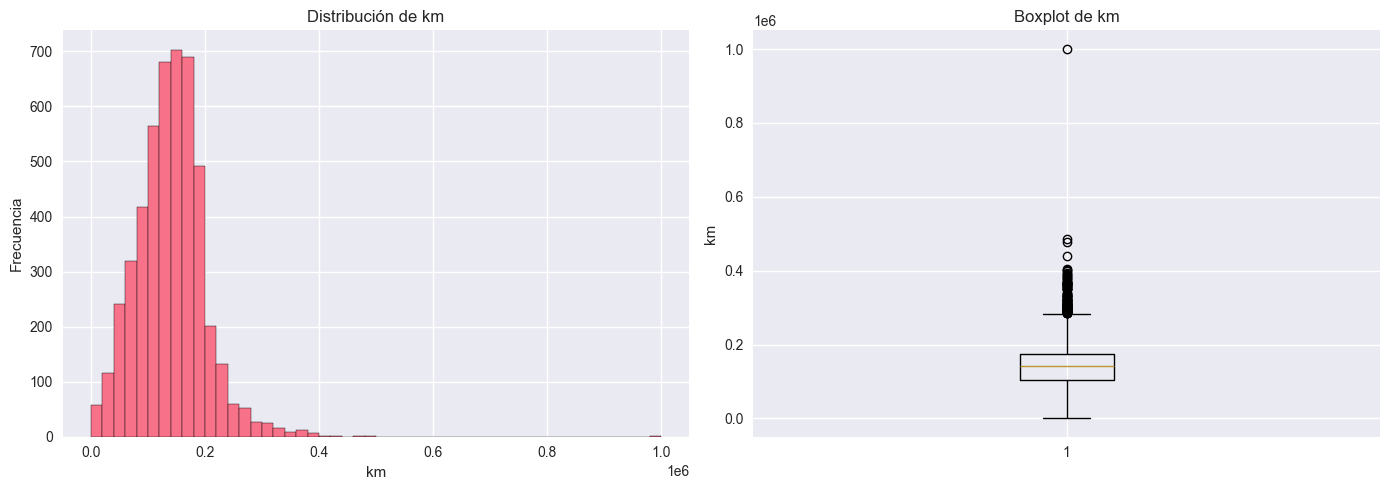


INSIGHT: Los coches tienen en promedio 140943 km
   El rango va desde 476 hasta 1000376 km

ANÁLISIS DE POTENCIA
count    4826.000000
mean      129.010568
std        38.960808
min        25.000000
25%       100.000000
50%       120.000000
75%       135.000000
max       423.000000
Name: potencia, dtype: float64


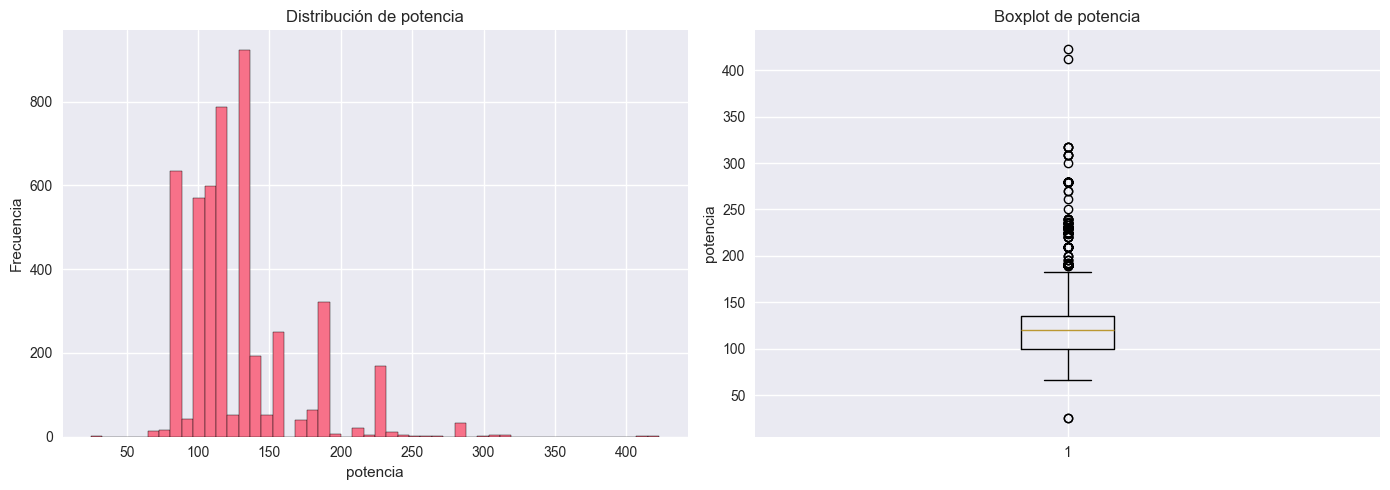


INSIGHT: La potencia media es 129.0 CV
   Potencia mínima: 25 CV, máxima: 423 CV

ANÁLISIS DE PRECIO
count      4826.000000
mean      15827.517613
std        9187.729434
min         100.000000
25%       10825.000000
50%       14200.000000
75%       18600.000000
max      178500.000000
Name: precio, dtype: float64


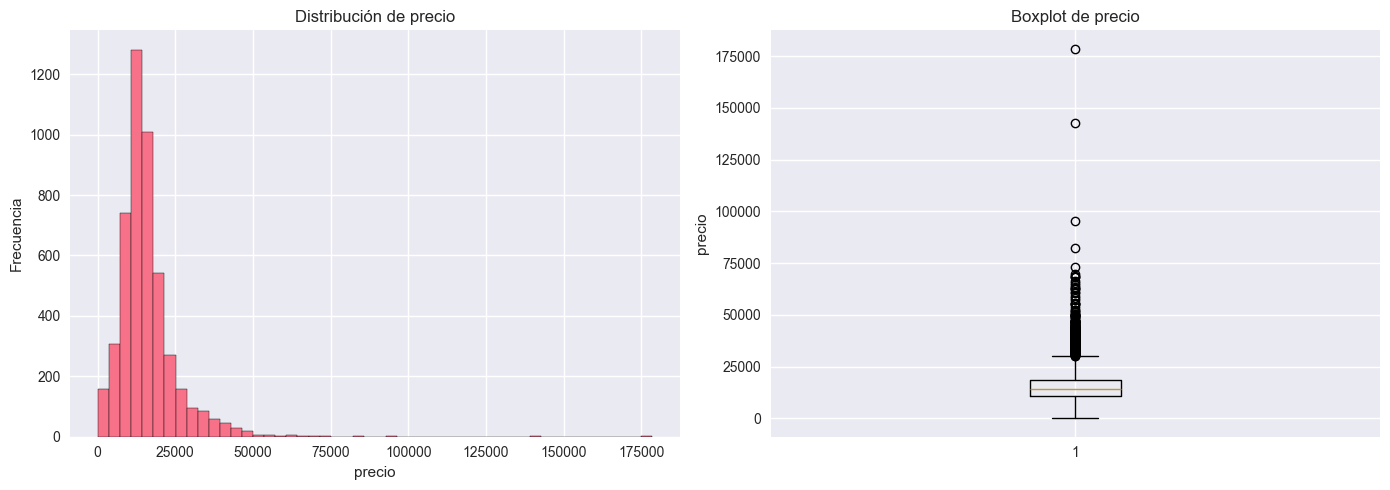


INSIGHT: El precio medio es 15827.52€
   El precio mediano es 14200.00€

ANÁLISIS DE EDAD_VEHICULO
count    4826.000000
mean        5.380483
std         2.407545
min         0.016427
25%         4.000000
50%         5.044490
75%         6.255989
max        28.084873
Name: EDAD_VEHICULO, dtype: float64


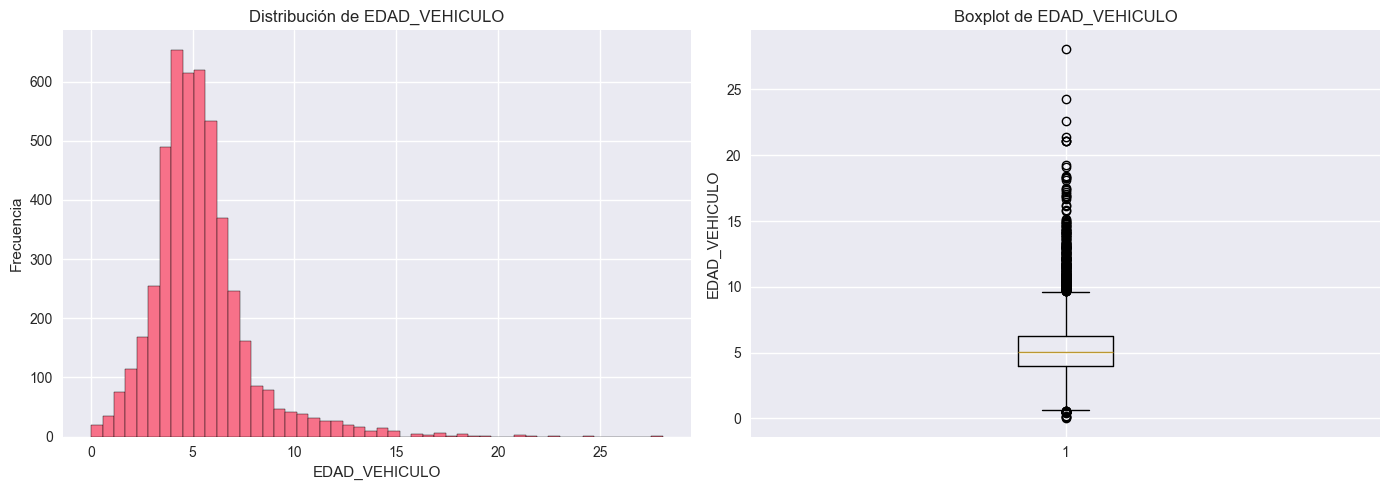

In [438]:
# ANÁLISIS DE VARIABLES NUMÉRICAS

variables_numericas = ['km', 'potencia', 'precio', 'EDAD_VEHICULO']

for var in variables_numericas:
    print(f"\n{'='*50}")
    print(f"ANÁLISIS DE {var.upper()}")
    print(f"{'='*50}")
    print(df_bmw_clean[var].describe())
    
    # Visualizaciones
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    axes[0].hist(df_bmw_clean[var].dropna(), bins=50, edgecolor='black')
    axes[0].set_title(f'Distribución de {var}')
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Frecuencia')
    
    # Boxplot
    axes[1].boxplot(df_bmw_clean[var].dropna())
    axes[1].set_title(f'Boxplot de {var}')
    axes[1].set_ylabel(var)
    
    plt.tight_layout()
    plt.show()
    
    # Información interesante
    if var == 'precio':
        print(f"\nINSIGHT: El precio medio es {df_bmw_clean[var].mean():.2f}€")
        print(f"   El precio mediano es {df_bmw_clean[var].median():.2f}€")
    elif var == 'km':
        print(f"\nINSIGHT: Los coches tienen en promedio {df_bmw_clean[var].mean():.0f} km")
        print(f"   El rango va desde {df_bmw_clean[var].min():.0f} hasta {df_bmw_clean[var].max():.0f} km")
    elif var == 'potencia':
        print(f"\nINSIGHT: La potencia media es {df_bmw_clean[var].mean():.1f} CV")
        print(f"   Potencia mínima: {df_bmw_clean[var].min():.0f} CV, máxima: {df_bmw_clean[var].max():.0f} CV")



ANÁLISIS DE MODELO

Top 10 valores más frecuentes:
modelo
320    749
520    631
318    567
x3     437
116    358
x1     273
316    233
x5     231
525    182
530    157
Name: count, dtype: int64

Número de categorías únicas: 76
Porcentaje del valor más frecuente: 15.52%


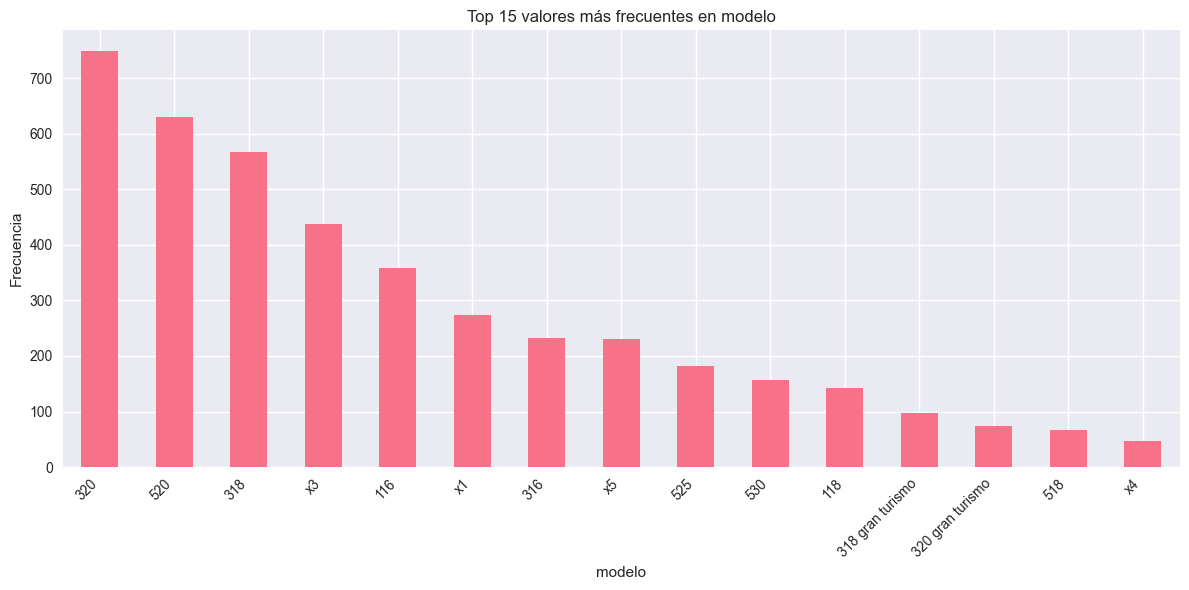


INSIGHT: El modelo más común es '320' con 749 unidades

ANÁLISIS DE TIPO_GASOLINA

Top 10 valores más frecuentes:
tipo_gasolina
diesel           4624
petrol            191
hybrid_petrol       8
electro             3
Name: count, dtype: int64

Número de categorías únicas: 4
Porcentaje del valor más frecuente: 95.81%


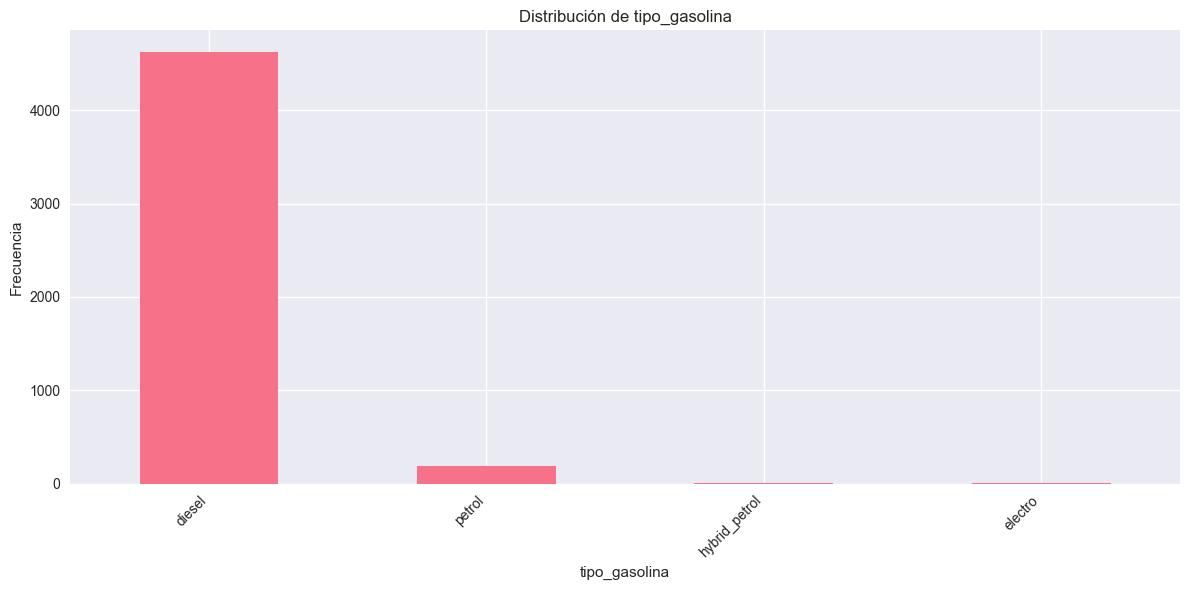


INSIGHT: diesel es el tipo de combustible más común
   Distribución: {'diesel': np.int64(4624), 'petrol': np.int64(191), 'hybrid_petrol': np.int64(8), 'electro': np.int64(3)}

ANÁLISIS DE COLOR

Top 10 valores más frecuentes:
color
black          1492
grey           1069
blue            643
white           482
desconocido     444
brown           302
silver          290
red              47
beige            37
green            14
Name: count, dtype: int64

Número de categorías únicas: 11
Porcentaje del valor más frecuente: 30.92%


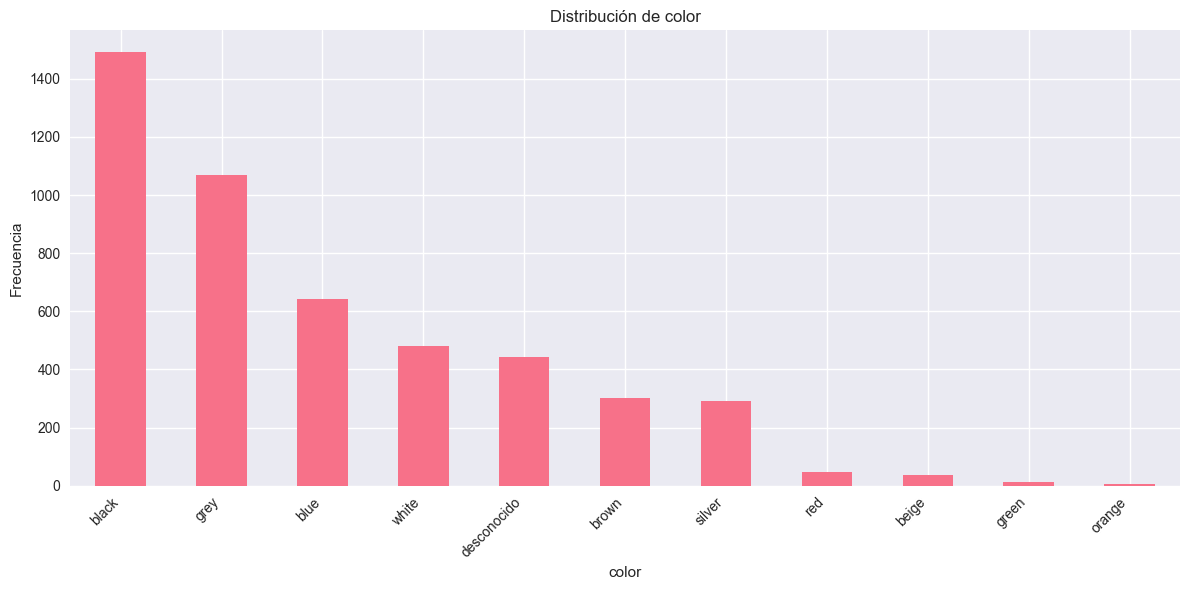


INSIGHT: El color más popular es 'black'

ANÁLISIS DE TIPO_COCHE

Top 10 valores más frecuentes:
tipo_coche
desconocido    1453
estate         1102
sedan           820
suv             753
hatchback       488
subcompact       77
coupe            75
convertible      30
van              28
Name: count, dtype: int64

Número de categorías únicas: 9
Porcentaje del valor más frecuente: 30.11%


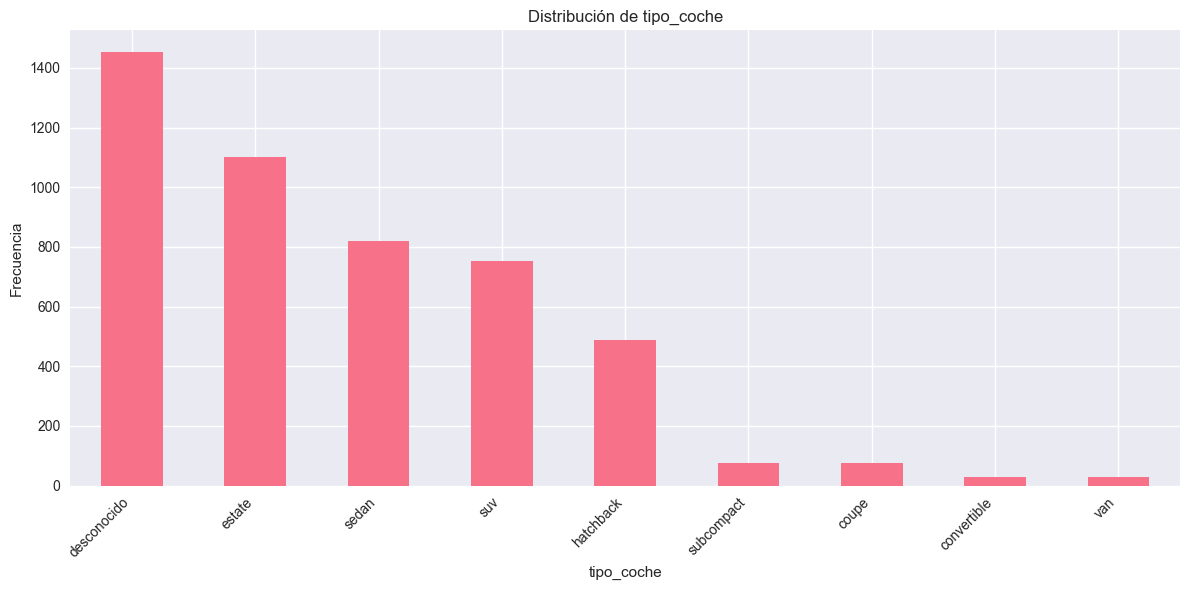

In [439]:
# ANÁLISIS DE VARIABLES CATEGÓRICAS

variables_categoricas = ['modelo', 'tipo_gasolina', 'color', 'tipo_coche']

for var in variables_categoricas:
    print(f"\n{'='*50}")
    print(f"ANÁLISIS DE {var.upper()}")
    print(f"{'='*50}")
    
    value_counts = df_bmw_clean[var].value_counts()
    print(f"\nTop 10 valores más frecuentes:")
    print(value_counts.head(10))
    
    print(f"\nNúmero de categorías únicas: {df_bmw_clean[var].nunique()}")
    print(f"Porcentaje del valor más frecuente: {(value_counts.iloc[0] / len(df_bmw_clean)) * 100:.2f}%")
    
    # Visualización
    plt.figure(figsize=(12, 6))
    if df_bmw_clean[var].nunique() > 20:
        # Si hay muchas categorías, mostramos solo las top 15
        top_values = value_counts.head(15)
        top_values.plot(kind='bar')
        plt.title(f'Top 15 valores más frecuentes en {var}')
    else:
        value_counts.plot(kind='bar')
        plt.title(f'Distribución de {var}')
    
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Insights
    if var == 'modelo':
        print(f"\nINSIGHT: El modelo más común es '{value_counts.index[0]}' con {value_counts.iloc[0]} unidades")
    elif var == 'tipo_gasolina':
        print(f"\nINSIGHT: {value_counts.index[0]} es el tipo de combustible más común")
        print(f"   Distribución: {dict(value_counts)}")
    elif var == 'color':
        print(f"\nINSIGHT: El color más popular es '{value_counts.index[0]}'")


DISTRIBUCIÓN DE VARIABLES BOOLEANAS:

volante_regulable:
  True: 2653 (55.0%)
  False: 2173 (45.0%)

aire_acondicionado:
  True: 3454 (71.6%)
  False: 1372 (28.4%)

camara_trasera:
  True: 971 (20.1%)
  False: 3855 (79.9%)

elevalunas_electrico:
  True: 2222 (46.0%)
  False: 2604 (54.0%)

bluetooth:
  True: 993 (20.6%)
  False: 3833 (79.4%)

gps:
  True: 4499 (93.2%)
  False: 327 (6.8%)

alerta_lim_velocidad:
  True: 2232 (46.2%)
  False: 2594 (53.8%)


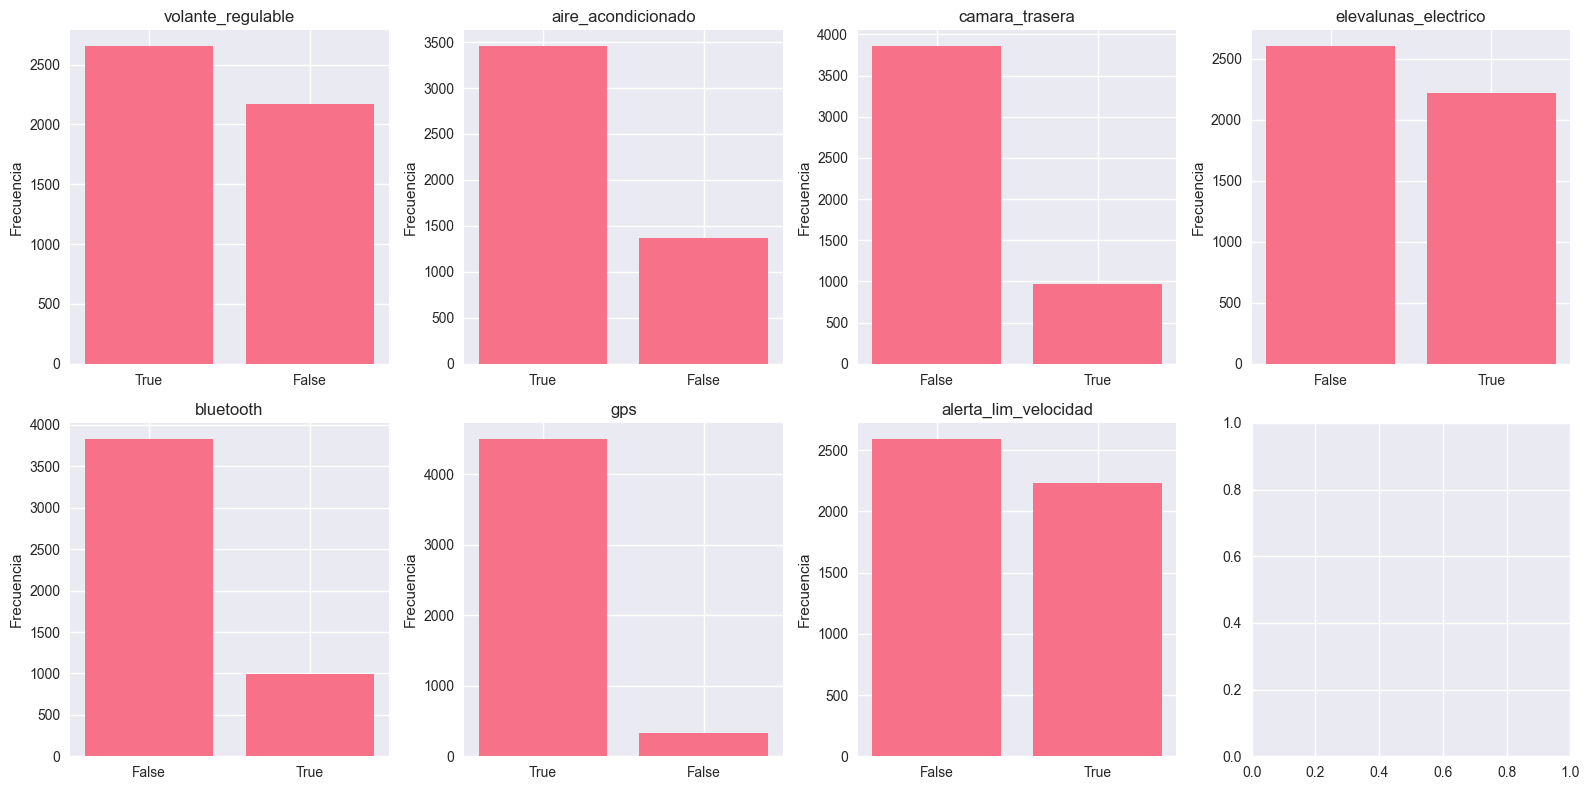

In [440]:
# ANÁLISIS DE VARIABLES BOOLEANAS

variables_booleanas = ['volante_regulable', 'aire_acondicionado', 'camara_trasera', 
                       'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad']

print("DISTRIBUCIÓN DE VARIABLES BOOLEANAS:")
print("="*60)

for var in variables_booleanas:
    value_counts = df_bmw_clean[var].value_counts()
    porcentaje_true = (value_counts.get(True, 0) / len(df_bmw_clean)) * 100
    print(f"\n{var}:")
    print(f"  True: {value_counts.get(True, 0)} ({porcentaje_true:.1f}%)")
    print(f"  False: {value_counts.get(False, 0)} ({100-porcentaje_true:.1f}%)")

# Visualización
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(variables_booleanas):
    value_counts = df_bmw_clean[var].value_counts()
    axes[i].bar(value_counts.index.astype(str), value_counts.values)
    axes[i].set_title(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


### 2.3. Análisis de Correlación

**Objetivo:** Identificar correlaciones entre variables y con el target para detectar riesgos de multicolinealidad y predictores importantes.


Matriz de correlación (variables numéricas):
                                 km  potencia    precio  EDAD_VEHICULO  \
km                         1.000000 -0.050034 -0.408978       0.730398   
potencia                  -0.050034  1.000000  0.639563      -0.080896   
precio                    -0.408978  0.639563  1.000000      -0.422933   
EDAD_VEHICULO              0.730398 -0.080896 -0.422933       1.000000   
fecha_registro_disponible -0.004447  0.015079  0.019686       0.006149   

                           fecha_registro_disponible  
km                                         -0.004447  
potencia                                    0.015079  
precio                                      0.019686  
EDAD_VEHICULO                               0.006149  
fecha_registro_disponible                   1.000000  


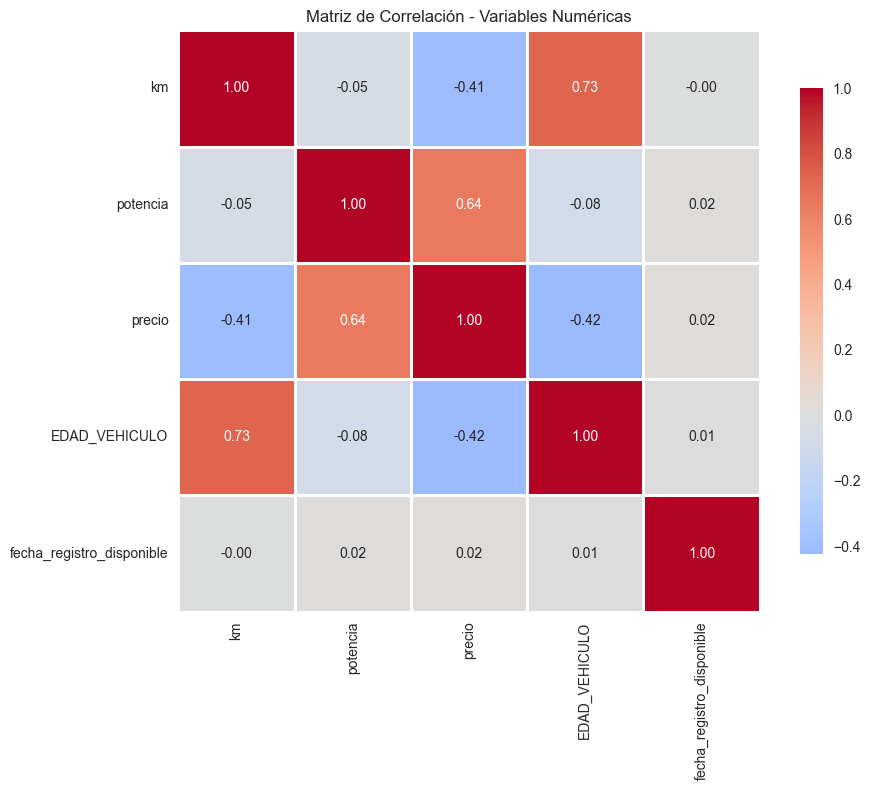

In [441]:
# Calculamos la matriz de correlación solo para variables numéricas
# La correlación mide la relación lineal entre variables

variables_numericas_corr = ['km', 'potencia', 'precio', 'EDAD_VEHICULO', 'fecha_registro_disponible']
corr = df_bmw_clean[variables_numericas_corr].corr()

print("Matriz de correlación (variables numéricas):")
print(corr)

# Visualización con mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()


In [442]:
# Identificamos pares de variables con alta correlación (|r| > 0.7)
# Estas variables pueden causar multicolinealidad

print("Pares de variables con correlación alta (|r| > 0.7):")
print("="*60)

# Obtenemos el triángulo superior de la matriz (sin la diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_triangulo = corr.where(mask)

# Buscamos correlaciones altas
for i in range(len(corr_triangulo.columns)):
    for j in range(i+1, len(corr_triangulo.columns)):
        valor = corr_triangulo.iloc[i, j]
        if not np.isnan(valor) and abs(valor) > 0.7:
            var1 = corr_triangulo.columns[i]
            var2 = corr_triangulo.columns[j]
            print(f"{var1} - {var2}: {valor:.3f}")

# Si no hay correlaciones altas
if corr_triangulo.abs().max().max() <= 0.7:
    print("No se encontraron correlaciones altas (|r| > 0.7) entre variables numéricas")
    print(f"Correlación máxima: {corr_triangulo.abs().max().max():.3f}")


Pares de variables con correlación alta (|r| > 0.7):
km - EDAD_VEHICULO: 0.730


### 2.4. Análisis Bivariable (Variables vs Target)

**Objetivo:** Analizar la relación entre cada predictor y `precio` (target) para identificar predictores fuertes e insights interesantes.



ANÁLISIS: KM vs PRECIO
Correlación con precio: -0.409


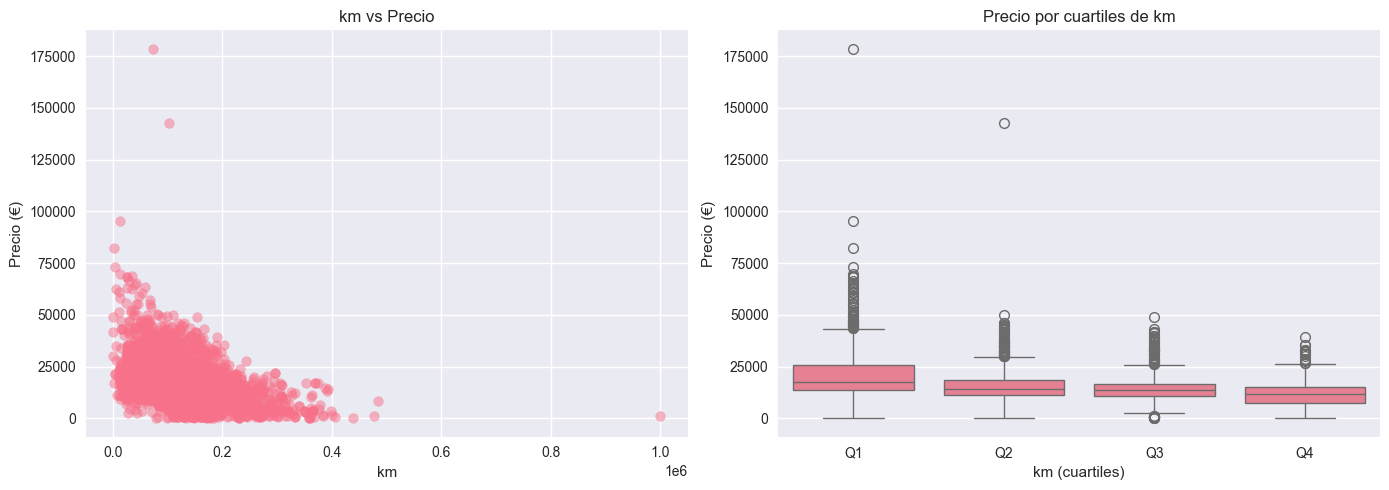


INSIGHT: Correlación negativa moderada/alta (-0.409)
   A mayor kilometraje, menor precio (correlación negativa esperada)

ANÁLISIS: POTENCIA vs PRECIO
Correlación con precio: 0.640


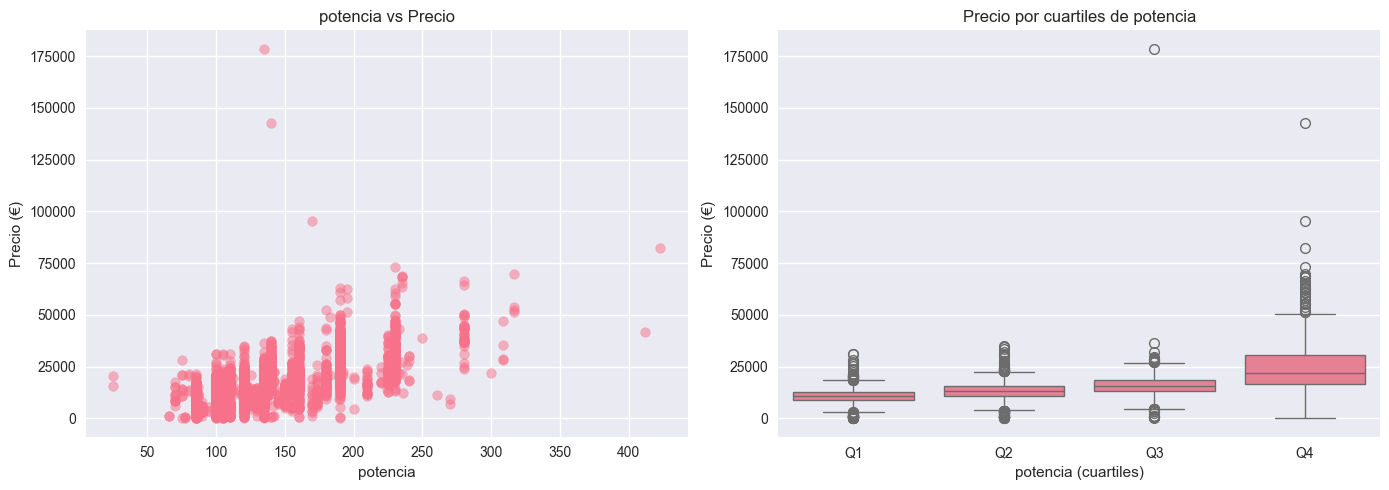


INSIGHT: Correlación positiva moderada/alta (0.640)
   A mayor potencia, mayor precio (correlación positiva esperada)

ANÁLISIS: EDAD_VEHICULO vs PRECIO
Correlación con precio: -0.423


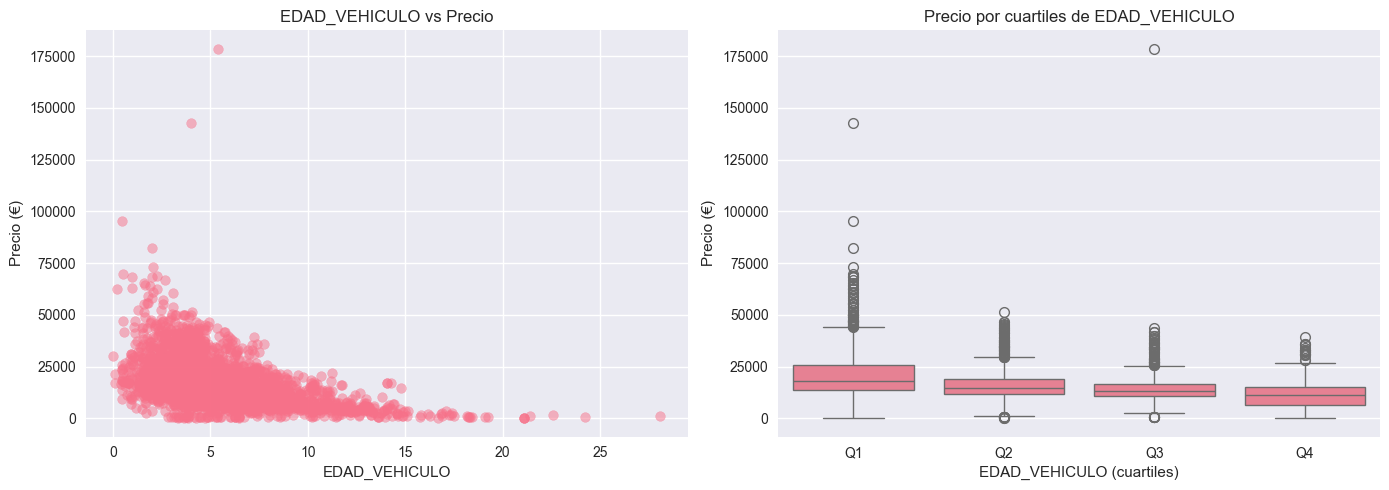


INSIGHT: Correlación negativa moderada/alta (-0.423)
   A mayor edad del vehículo, menor precio (correlación negativa esperada)


In [443]:
# ANÁLISIS: Variables numéricas vs Precio

variables_numericas_vs_target = ['km', 'potencia', 'EDAD_VEHICULO']

for var in variables_numericas_vs_target:
    print(f"\n{'='*50}")
    print(f"ANÁLISIS: {var.upper()} vs PRECIO")
    print(f"{'='*50}")
    
    # Correlación
    correlacion = df_bmw_clean[var].corr(df_bmw_clean['precio'])
    print(f"Correlación con precio: {correlacion:.3f}")
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(df_bmw_clean[var], df_bmw_clean['precio'], alpha=0.5)
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Precio (€)')
    axes[0].set_title(f'{var} vs Precio')
    
    # Boxplot por cuartiles
    df_bmw_clean[f'{var}_quartile'] = pd.qcut(df_bmw_clean[var], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    sns.boxplot(data=df_bmw_clean, x=f'{var}_quartile', y='precio', ax=axes[1])
    axes[1].set_title(f'Precio por cuartiles de {var}')
    axes[1].set_xlabel(f'{var} (cuartiles)')
    axes[1].set_ylabel('Precio (€)')
    
    plt.tight_layout()
    plt.show()
    
    # Eliminamos la columna temporal
    df_bmw_clean.drop(columns=[f'{var}_quartile'], inplace=True)
    
    # Insight
    if abs(correlacion) > 0.3:
        direccion = "positiva" if correlacion > 0 else "negativa"
        print(f"\nINSIGHT: Correlación {direccion} moderada/alta ({correlacion:.3f})")
        if var == 'km':
            print("   A mayor kilometraje, menor precio (correlación negativa esperada)")
        elif var == 'potencia':
            print("   A mayor potencia, mayor precio (correlación positiva esperada)")
        elif var == 'EDAD_VEHICULO':
            print("   A mayor edad del vehículo, menor precio (correlación negativa esperada)")
    else:
        print(f"\nINSIGHT: Correlación débil con precio ({correlacion:.3f})")



ANÁLISIS: MODELO vs PRECIO

Precio medio por categoría (top 10):
                        mean   median  count
modelo                                      
i8              95200.000000  95200.0      1
m4              61650.000000  61650.0      2
x6 m            51050.000000  45800.0      8
x5 m50          49533.333333  49900.0      3
m5              41600.000000  41600.0      1
x5 m            37788.235294  40900.0     17
740             37772.222222  30950.0     18
750             37200.000000  37200.0      2
640 gran coupé  37066.666667  35150.0     18
m3              36428.571429  35700.0      7


/var/folders/ps/jqlt68cn4jj4sxcmj_4y13zh0000gn/T/ipykernel_43141/2528085273.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


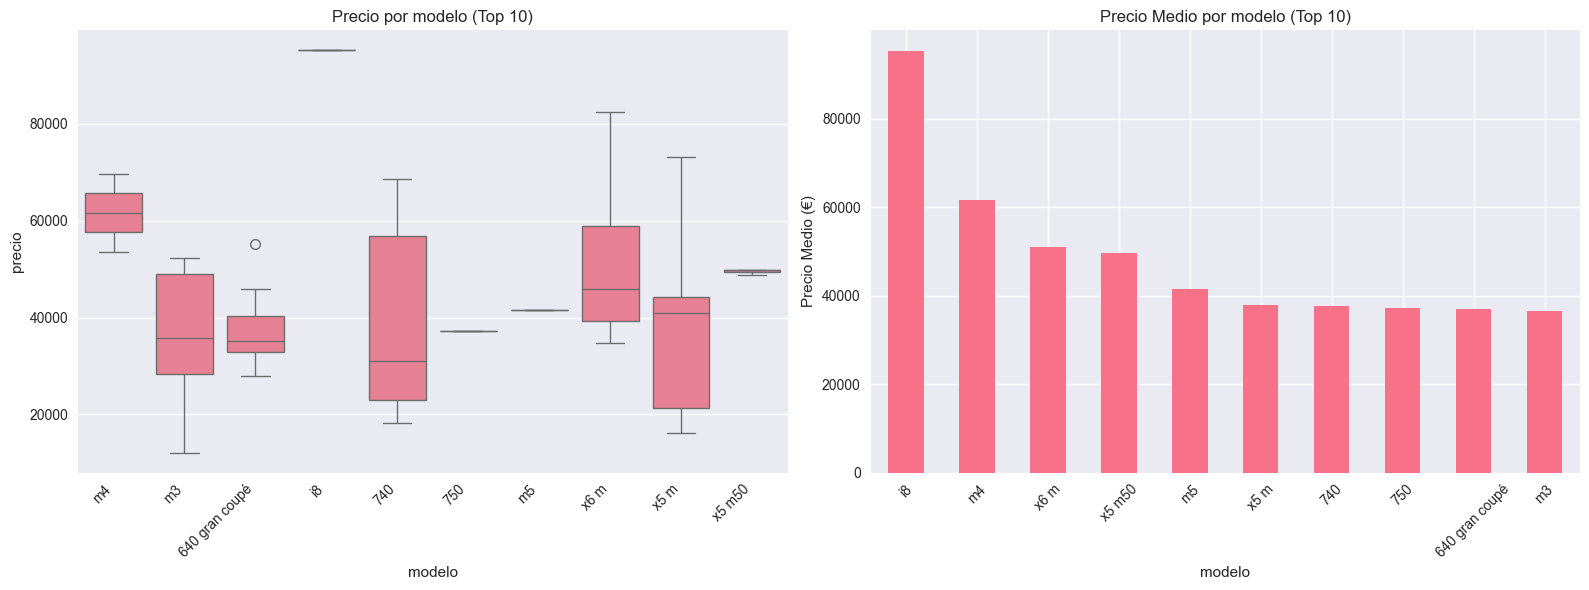


INSIGHT:
   Categoría más cara: i8 (precio medio: 95200.00€)
   Categoría más barata: 735 (precio medio: 4500.00€)
   Diferencia: 90700.00€

ANÁLISIS: TIPO_GASOLINA vs PRECIO

Precio medio por categoría (top 10):
                       mean   median  count
tipo_gasolina                              
hybrid_petrol  37575.000000  25000.0      8
electro        20966.666667  20900.0      3
diesel         15845.588235  14300.0   4624
petrol         14398.429319  11900.0    191


/var/folders/ps/jqlt68cn4jj4sxcmj_4y13zh0000gn/T/ipykernel_43141/2528085273.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


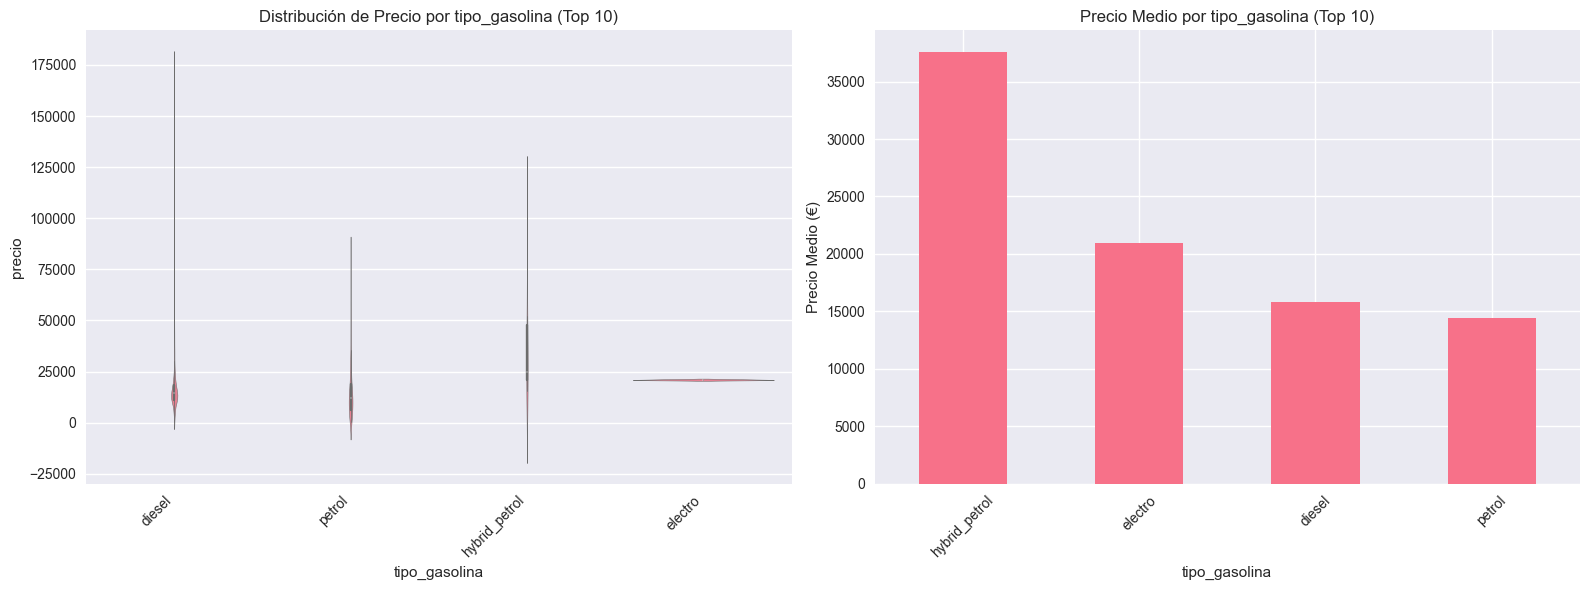


INSIGHT:
   Categoría más cara: hybrid_petrol (precio medio: 37575.00€)
   Categoría más barata: petrol (precio medio: 14398.43€)
   Diferencia: 23176.57€

ANÁLISIS: COLOR vs PRECIO

Precio medio por categoría (top 10):
                     mean   median  count
color                                    
orange       18866.666667  17400.0      6
white        17293.775934  14900.0    482
red          16642.553191  13400.0     47
black        16166.487936  14550.0   1492
grey         15613.844715  14000.0   1069
brown        15545.695364  13900.0    302
desconocido  15526.576577  13750.0    444
blue         15226.127527  13400.0    643
beige        14916.216216  13600.0     37
silver       14872.413793  14250.0    290


/var/folders/ps/jqlt68cn4jj4sxcmj_4y13zh0000gn/T/ipykernel_43141/2528085273.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


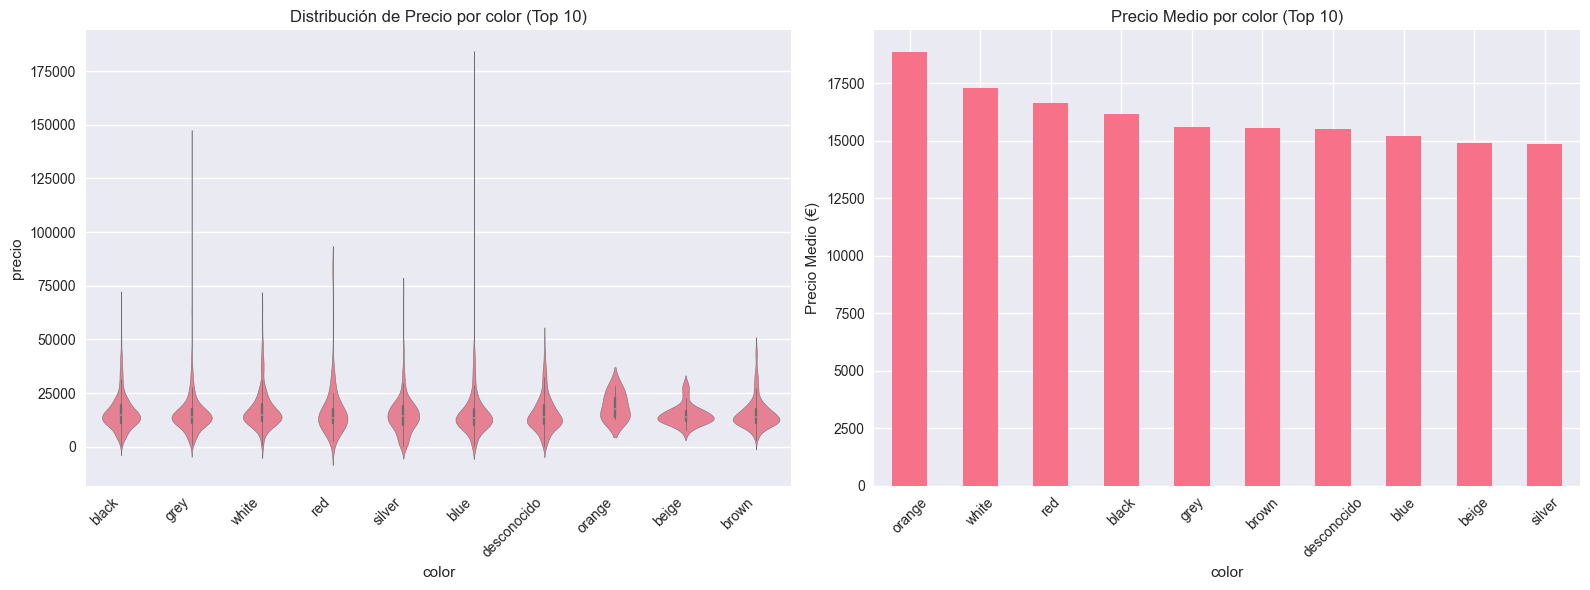


INSIGHT:
   Categoría más cara: orange (precio medio: 18866.67€)
   Categoría más barata: green (precio medio: 6935.71€)
   Diferencia: 11930.95€

ANÁLISIS: TIPO_COCHE vs PRECIO

Precio medio por categoría (top 10):
                     mean   median  count
tipo_coche                               
coupe        22518.666667  23100.0     75
suv          21767.197875  17800.0    753
convertible  16796.666667  12100.0     30
sedan        16015.000000  14900.0    820
desconocido  15587.061253  14200.0   1453
van          14646.428571  14100.0     28
hatchback    13275.819672  11900.0    488
estate       13050.544465  12950.0   1102
subcompact    9732.467532   9300.0     77


/var/folders/ps/jqlt68cn4jj4sxcmj_4y13zh0000gn/T/ipykernel_43141/2528085273.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


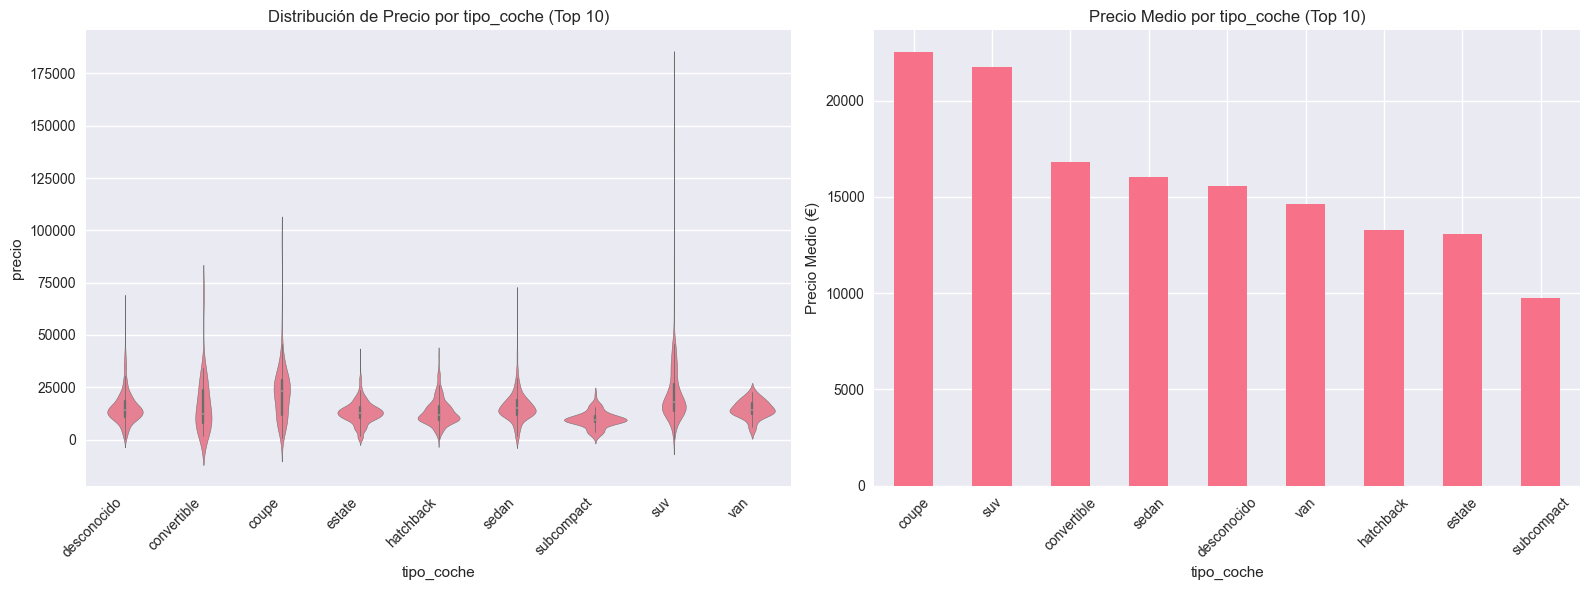


INSIGHT:
   Categoría más cara: coupe (precio medio: 22518.67€)
   Categoría más barata: subcompact (precio medio: 9732.47€)
   Diferencia: 12786.20€


In [444]:
# ANÁLISIS: Variables categóricas vs Precio

variables_categoricas_vs_target = ['modelo', 'tipo_gasolina', 'color', 'tipo_coche']

for var in variables_categoricas_vs_target:
    print(f"\n{'='*50}")
    print(f"ANÁLISIS: {var.upper()} vs PRECIO")
    print(f"{'='*50}")
    
    # Estadísticas por categoría
    stats_por_categoria = df_bmw_clean.groupby(var)['precio'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
    print(f"\nPrecio medio por categoría (top 10):")
    print(stats_por_categoria.head(10))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Violin plot (si hay pocas categorías) o boxplot
    if df_bmw_clean[var].nunique() <= 15:
        # Violin plot para ver distribución
        top_categorias = stats_por_categoria.head(10).index
        df_top = df_bmw_clean[df_bmw_clean[var].isin(top_categorias)]
        sns.violinplot(data=df_top, x=var, y='precio', ax=axes[0])
        axes[0].set_title(f'Distribución de Precio por {var} (Top 10)')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    else:
        # Boxplot para muchas categorías
        top_categorias = stats_por_categoria.head(10).index
        df_top = df_bmw_clean[df_bmw_clean[var].isin(top_categorias)]
        sns.boxplot(data=df_top, x=var, y='precio', ax=axes[0])
        axes[0].set_title(f'Precio por {var} (Top 10)')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    
    # Precio medio por categoría
    top_10_mean = stats_por_categoria.head(10)
    top_10_mean['mean'].plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'Precio Medio por {var} (Top 10)')
    axes[1].set_xlabel(var)
    axes[1].set_ylabel('Precio Medio (€)')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Insight
    categoria_mas_cara = stats_por_categoria.index[0]
    categoria_mas_barata = stats_por_categoria.index[-1]
    diferencia = stats_por_categoria.loc[categoria_mas_cara, 'mean'] - stats_por_categoria.loc[categoria_mas_barata, 'mean']
    
    print(f"\nINSIGHT:")
    print(f"   Categoría más cara: {categoria_mas_cara} (precio medio: {stats_por_categoria.loc[categoria_mas_cara, 'mean']:.2f}€)")
    print(f"   Categoría más barata: {categoria_mas_barata} (precio medio: {stats_por_categoria.loc[categoria_mas_barata, 'mean']:.2f}€)")
    print(f"   Diferencia: {diferencia:.2f}€")


Impacto de características booleanas en el precio:

volante_regulable:
  Con volante_regulable: 18065.13€ (n=2653)
  Sin volante_regulable: 13095.63€ (n=2173)
  Diferencia: +4969.51€ (+37.9%)

aire_acondicionado:
  Con aire_acondicionado: 17035.32€ (n=3454)
  Sin aire_acondicionado: 12786.88€ (n=1372)
  Diferencia: +4248.44€ (+33.2%)

camara_trasera:
  Con camara_trasera: 20471.58€ (n=971)
  Sin camara_trasera: 14657.77€ (n=3855)
  Diferencia: +5813.81€ (+39.7%)

elevalunas_electrico:
  Con elevalunas_electrico: 18440.19€ (n=2222)
  Sin elevalunas_electrico: 13598.12€ (n=2604)
  Diferencia: +4842.07€ (+35.6%)

bluetooth:
  Con bluetooth: 19169.79€ (n=993)
  Sin bluetooth: 14961.65€ (n=3833)
  Diferencia: +4208.14€ (+28.1%)

gps:
  Con gps: 15809.89€ (n=4499)
  Sin gps: 16070.03€ (n=327)
  Diferencia: -260.14€ (-1.6%)

alerta_lim_velocidad:
  Con alerta_lim_velocidad: 19606.85€ (n=2232)
  Sin alerta_lim_velocidad: 12575.60€ (n=2594)
  Diferencia: +7031.26€ (+55.9%)


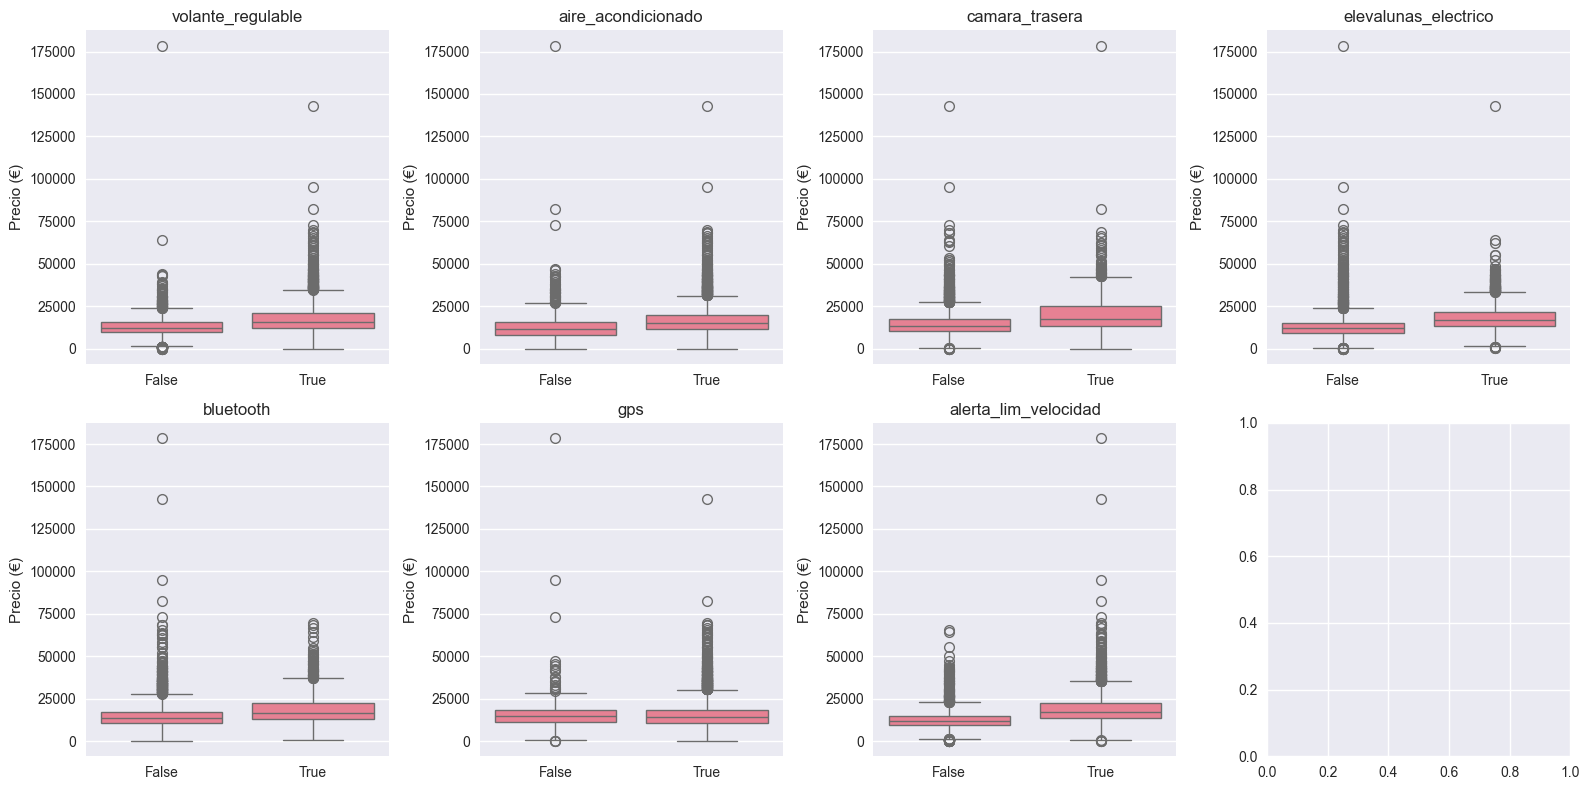

In [445]:
# ANÁLISIS: Variables booleanas vs Precio

variables_booleanas_vs_target = ['volante_regulable', 'aire_acondicionado', 'camara_trasera', 
                                  'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad']

print("Impacto de características booleanas en el precio:")
print("="*60)

for var in variables_booleanas_vs_target:
    stats = df_bmw_clean.groupby(var)['precio'].agg(['mean', 'median', 'count'])
    diferencia = stats.loc[True, 'mean'] - stats.loc[False, 'mean']
    porcentaje_diferencia = (diferencia / stats.loc[False, 'mean']) * 100
    
    print(f"\n{var}:")
    print(f"  Con {var}: {stats.loc[True, 'mean']:.2f}€ (n={stats.loc[True, 'count']})")
    print(f"  Sin {var}: {stats.loc[False, 'mean']:.2f}€ (n={stats.loc[False, 'count']})")
    print(f"  Diferencia: {diferencia:+.2f}€ ({porcentaje_diferencia:+.1f}%)")

# Visualización
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(variables_booleanas_vs_target):
    sns.boxplot(data=df_bmw_clean, x=var, y='precio', ax=axes[i])
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Precio (€)')

plt.tight_layout()
plt.show()


---

## PARTE 3: TRANSFORMACIÓN DE VARIABLES Y PREPARACIÓN PARA MODELADO

> **Objetivo:** Transformar variables categóricas a formato numérico y estandarizar/ escalar features para algoritmos de machine learning. (Matteo prefiere la estandarización y nos lo ha demostrado con el Perceptrón, pero aquí seguiremos las instrucciones de Alberto)

### 3.1. Codificación de Variables Categóricas

**Objetivo:** Convertir 4 variables categóricas (modelo, tipo_gasolina, color, tipo_coche) a formato numérico usando One-Hot Encoding


In [428]:
# Identificamos el tipo de cada variable para decidir la transformación adecuada

target = ['precio']  # Variable objetivo

def obtener_lista_variables(dataset, target):
    """
    Clasifica las variables en numéricas, booleanas y categóricas.
    """
    lista_numericas = []
    lista_boolean = []
    lista_categoricas = []
    
    for col in dataset.columns:
        if col in target:
            continue
        
        # Variables numéricas (float o int) con más de 2 valores únicos
        if dataset[col].dtype.kind in ('f', 'i') and len(dataset[col].unique()) > 2:
            lista_numericas.append(col)
        # Variables booleanas (bool o con solo 2 valores únicos)
        elif dataset[col].dtype == bool or (dataset[col].dtype.kind in ('f', 'i', 'O') and len(dataset[col].unique()) == 2):
            lista_boolean.append(col)
        # Variables categóricas (object o con pocos valores únicos)
        elif dataset[col].dtype.kind == 'O':
            lista_categoricas.append(col)
        # Variables datetime no se incluyen directamente
    
    return lista_numericas, lista_boolean, lista_categoricas

lista_numericas, lista_boolean, lista_categoricas = obtener_lista_variables(df_bmw_clean, target)

print("Clasificación de variables:")
print("="*60)
print(f"\nVariables NUMÉRICAS ({len(lista_numericas)}):")
for var in lista_numericas:
    print(f"  - {var}")

print(f"\nVariables BOOLEANAS ({len(lista_boolean)}):")
for var in lista_boolean:
    print(f"  - {var}")

print(f"\nVariables CATEGÓRICAS ({len(lista_categoricas)}):")
for var in lista_categoricas:
    n_categorias = df_bmw_clean[var].nunique()
    print(f"  - {var} ({n_categorias} categorías)")


Clasificación de variables:

Variables NUMÉRICAS (3):
  - km
  - potencia
  - EDAD_VEHICULO

Variables BOOLEANAS (8):
  - volante_regulable
  - aire_acondicionado
  - camara_trasera
  - elevalunas_electrico
  - bluetooth
  - gps
  - alerta_lim_velocidad
  - fecha_registro_disponible

Variables CATEGÓRICAS (4):
  - modelo (76 categorías)
  - tipo_gasolina (4 categorías)
  - color (11 categorías)
  - tipo_coche (9 categorías)


In [429]:
# Analizamos las variables categóricas para decidir la técnica de encoding

print("Análisis de variables categóricas para encoding:")
print("="*60)

for var in lista_categoricas:
    n_categorias = df_bmw_clean[var].nunique()
    distribucion = df_bmw_clean[var].value_counts()
    
    print(f"\n{var}:")
    print(f"  Número de categorías: {n_categorias}")
    print(f"  Top 5 categorías:")
    for cat, count in distribucion.head(5).items():
        porcentaje = (count / len(df_bmw_clean)) * 100
        print(f"    - {cat}: {count} ({porcentaje:.1f}%)")
    
    # Decisión de técnica
    if n_categorias <= 10:
        print(f"  → TÉCNICA: One-Hot Encoding (OHE) - pocas categorías")
    else:
        print(f"  → TÉCNICA: One-Hot Encoding (OHE) o Target Encoding - muchas categorías")
        print(f"    Considerar agrupar categorías poco frecuentes si hay muchas")


Análisis de variables categóricas para encoding:

modelo:
  Número de categorías: 76
  Top 5 categorías:
    - 320: 749 (15.5%)
    - 520: 631 (13.1%)
    - 318: 567 (11.7%)
    - x3: 437 (9.1%)
    - 116: 358 (7.4%)
  → TÉCNICA: One-Hot Encoding (OHE) o Target Encoding - muchas categorías
    Considerar agrupar categorías poco frecuentes si hay muchas

tipo_gasolina:
  Número de categorías: 4
  Top 5 categorías:
    - diesel: 4624 (95.8%)
    - petrol: 191 (4.0%)
    - hybrid_petrol: 8 (0.2%)
    - electro: 3 (0.1%)
  → TÉCNICA: One-Hot Encoding (OHE) - pocas categorías

color:
  Número de categorías: 11
  Top 5 categorías:
    - black: 1492 (30.9%)
    - grey: 1069 (22.2%)
    - blue: 643 (13.3%)
    - white: 482 (10.0%)
    - desconocido: 444 (9.2%)
  → TÉCNICA: One-Hot Encoding (OHE) o Target Encoding - muchas categorías
    Considerar agrupar categorías poco frecuentes si hay muchas

tipo_coche:
  Número de categorías: 9
  Top 5 categorías:
    - desconocido: 1453 (30.1%)
    - es

#### 3.0.5. Agrupación de Variables Categóricas de Alta Cardinalidad

**Problema:** `modelo` tiene 76 categorías (muchas con <50 registros) y `color` tiene 11 categorías con algunas muy poco frecuentes.

**Solución:** Aplicar agrupación inteligente para reducir dimensionalidad sin perder información predictiva:

**MODELO - Agrupación Híbrida:**
- Mantener modelos frecuentes (>200 registros) separados: 320, 520, 318, X3, 116, X1, 316, X5
- Agrupar modelos raros (<200 registros) por SERIE BMW: 1-Series, 2-Series, 3-Series, 4-Series, 5-Series, 6-Series, 7-Series, X-Series, M-Series, i-Series, Z-Series
- Reducción: 76 -> 21 categorías (-72%)

**COLOR - Agrupación Híbrida:**
Solo se agrupan categorías con patrón de precio similar y suficiente coherencia visual y estadística. No se agrupan categorías con comportamientos muy distintos, y precios promedios que no se parecen a otros, como "orange" o "green".

- Básics (black, white, grey, silver): 69.06% de datos.
- Azul: 13.32%
- Brown_beige: 7.02%
- Desconocido: 9.20%
- Orange : 0.12%
- Red: 0.97%
- Green: 0.29%
- Reducción: 11 -> 7 categorías únicas

**Impacto:** Reduce dimensionalidad de 87 -> 24 columnas dummy (-72.4%), manteniendo información predictiva relevante.
Categorías únicas: 7

In [430]:
# AGRUPACIÓN DE VARIABLES CATEGÓRICAS
import re

# 1. MODELO - Agrupación Híbrida
# Contamos frecuencia de cada modelo
modelo_freq = df_bmw_clean['modelo'].value_counts()

def extract_serie(modelo):
    """Extrae la serie BMW del modelo (para modelos raros)"""
    if pd.isna(modelo):
        return 'Unknown'
    
    modelo = str(modelo).strip()
    
    # Series especiales
    if modelo.startswith('X'):
        return 'X-Series'
    elif modelo.startswith('i'):
        return 'i-Series'
    elif modelo.startswith('M'):
        return 'M-Series'
    elif modelo.startswith('Z'):
        return 'Z-Series'
    # Series numéricas (1, 2, 3, 4, 5, 6, 7)
    else:
        match = re.match(r'(\d)', modelo)
        if match:
            serie_num = match.group(1)
            return f'{serie_num}-Series'
        else:
            return 'Other'

def hybrid_grouping_modelo(modelo):
    """Mantiene modelos frecuentes separados, agrupa raros por serie"""
    if pd.isna(modelo):
        return 'Unknown'
    
    freq = modelo_freq.get(modelo, 0)
    
    # Mantener modelos muy frecuentes (>200 registros)
    if freq >= 200:
        return modelo
    # Agrupar modelos raros por serie
    else:
        return extract_serie(modelo)

# Aplicar agrupación a modelo
df_bmw_clean['modelo'] = df_bmw_clean['modelo'].apply(hybrid_grouping_modelo)

print("AGRUPACIÓN DE MODELO:")
print(f"Categorías únicas: {df_bmw_clean['modelo'].nunique()}")
print(f"\nTop 10 categorías:")
for cat, count in df_bmw_clean['modelo'].value_counts().head(10).items():
    pct = count / len(df_bmw_clean) * 100
    print(f"  {cat:20s}: {count:4d} ({pct:5.2f}%)")

# 2. COLOR - Agrupación Híbrida
def group_color(color):
    """Agrupa colores por familia"""
    if pd.isna(color):
        return 'Desconocido'
    
    color = str(color).lower().strip()
    
    # Básicos monocromáticos (los más comunes)
    if color in ['black', 'white', 'grey', 'silver']:
        return 'basics'
    # Marrones/neutros
    elif color in ['brown', 'beige']:
        return 'brown_beige'
    # Desconocido
    elif color in ['desconocido', 'nan']:
        return 'desconocido'
    else:
        return color

# Aplicar agrupación a color
df_bmw_clean['color'] = df_bmw_clean['color'].apply(group_color)

print("\n" + "="*60)
print("\nAGRUPACIÓN DE COLOR:")
print(f"Categorías únicas: {df_bmw_clean['color'].nunique()}")
print(f"\nDistribución:")
for cat, count in df_bmw_clean['color'].value_counts().items():
    pct = count / len(df_bmw_clean) * 100
    print(f"  {cat:20s}: {count:4d} ({pct:5.2f}%)")

print("\n" + "="*60)
print(f"\nREDUCCIÓN TOTAL:")
print(f"  Antes: 76 (modelo) + 11 (color) = 87 columnas dummy")
print(f"  Después: {df_bmw_clean['modelo'].nunique()} (modelo) + {df_bmw_clean['color'].nunique()} (color) = {df_bmw_clean['modelo'].nunique() + df_bmw_clean['color'].nunique()} columnas dummy")
print(f"  Ahorro: {87 - (df_bmw_clean['modelo'].nunique() + df_bmw_clean['color'].nunique())} columnas (-{100 * (87 - (df_bmw_clean['modelo'].nunique() + df_bmw_clean['color'].nunique())) / 87:.1f}%)")


AGRUPACIÓN DE MODELO:
Categorías únicas: 17

Top 10 categorías:
  320                 :  749 (15.52%)
  520                 :  631 (13.08%)
  318                 :  567 (11.75%)
  5-Series            :  504 (10.44%)
  x3                  :  437 ( 9.06%)
  116                 :  358 ( 7.42%)
  x1                  :  273 ( 5.66%)
  3-Series            :  244 ( 5.06%)
  316                 :  233 ( 4.83%)
  x5                  :  231 ( 4.79%)


AGRUPACIÓN DE COLOR:
Categorías únicas: 7

Distribución:
  basics              : 3333 (69.06%)
  blue                :  643 (13.32%)
  desconocido         :  444 ( 9.20%)
  brown_beige         :  339 ( 7.02%)
  red                 :   47 ( 0.97%)
  green               :   14 ( 0.29%)
  orange              :    6 ( 0.12%)


REDUCCIÓN TOTAL:
  Antes: 76 (modelo) + 11 (color) = 87 columnas dummy
  Después: 17 (modelo) + 7 (color) = 24 columnas dummy
  Ahorro: 63 columnas (-72.4%)


In [431]:
# Aplicamos One-Hot Encoding a las variables categóricas
# OHE crea una columna binaria para cada categoría

print("Aplicando One-Hot Encoding a variables categóricas...")
print(f"Variables a transformar: {lista_categoricas}")

df_bmw_prep = pd.get_dummies(data=df_bmw_clean, columns=lista_categoricas, dtype=int)

print(f"\nDimensiones antes de OHE: {df_bmw_clean.shape}")
print(f"Dimensiones después de OHE: {df_bmw_prep.shape}")
print(f"Columnas nuevas creadas: {df_bmw_prep.shape[1] - df_bmw_clean.shape[1]}")

# Mostramos algunas columnas nuevas
print(f"\nEjemplo de columnas nuevas (primeras 10):")
nuevas_columnas = [col for col in df_bmw_prep.columns if col not in df_bmw_clean.columns]
print(nuevas_columnas[:10])


Aplicando One-Hot Encoding a variables categóricas...
Variables a transformar: ['modelo', 'tipo_gasolina', 'color', 'tipo_coche']

Dimensiones antes de OHE: (4826, 18)
Dimensiones después de OHE: (4826, 51)
Columnas nuevas creadas: 33

Ejemplo de columnas nuevas (primeras 10):
['modelo_1-Series', 'modelo_116', 'modelo_2-Series', 'modelo_3-Series', 'modelo_316', 'modelo_318', 'modelo_320', 'modelo_4-Series', 'modelo_5-Series', 'modelo_520']


In [432]:
# Normalizamos las variables numéricas usando MinMaxScaler
# MinMaxScaler escala los valores al rango [0, 1]
# Esto es importante para algoritmos que son sensibles a la escala o a valores negativos

print("Normalizando variables numéricas con MinMaxScaler...")
print(f"Variables a normalizar: {lista_numericas}")

# Creamos el scaler
scaler = MinMaxScaler()

# Aplicamos la normalización
df_bmw_prep[lista_numericas] = scaler.fit_transform(df_bmw_prep[lista_numericas])

print("\nVerificación de la normalización:")
print(df_bmw_prep[lista_numericas].describe())

# Verificamos que los valores estén en el rango [0, 1]
print(f"\nRango de valores después de normalización:")
for var in lista_numericas:
    min_val = df_bmw_prep[var].min()
    max_val = df_bmw_prep[var].max()
    print(f"  {var}: [{min_val:.3f}, {max_val:.3f}]")


Normalizando variables numéricas con MinMaxScaler...
Variables a normalizar: ['km', 'potencia', 'EDAD_VEHICULO']

Verificación de la normalización:
                km     potencia  EDAD_VEHICULO
count  4826.000000  4826.000000    4826.000000
mean      0.140481     0.261333       0.191106
std       0.060134     0.097891       0.085774
min       0.000000     0.000000       0.000000
25%       0.102397     0.188442       0.141924
50%       0.140612     0.238693       0.179136
75%       0.174772     0.276382       0.222298
max       1.000000     1.000000       1.000000

Rango de valores después de normalización:
  km: [0.000, 1.000]
  potencia: [0.000, 1.000]
  EDAD_VEHICULO: [0.000, 1.000]


In [433]:
# Verificamos el estado final del dataset preparado
print("Estado final del dataset preparado:")
print("="*60)
print(f"Dimensiones: {df_bmw_prep.shape}")
print(f"\nTipos de datos:")
print(df_bmw_prep.dtypes.value_counts())

print(f"\nPrimeras filas:")
df_bmw_prep.head()


Estado final del dataset preparado:
Dimensiones: (4826, 51)

Tipos de datos:
int64             37
bool               8
float64            4
datetime64[ns]     2
Name: count, dtype: int64

Primeras filas:


,km,potencia,fecha_registro,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,...,color_red,tipo_coche_convertible,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van
0,0.139949,0.188442,2012-02-01 00:00:00.000000000,True,True,False,True,False,True,False,...,0,0,0,1,0,0,0,0,0,0
1,0.013454,0.733668,2017-07-22 15:14:56.469719357,True,True,False,False,True,True,True,...,0,1,0,0,0,0,0,0,0,0
2,0.182839,0.238693,2012-04-01 00:00:00.000000000,False,False,False,True,False,True,False,...,0,0,0,1,0,0,0,0,0,0
3,0.127572,0.276382,2013-03-21 14:20:22.535754084,True,True,False,True,True,True,False,...,1,1,0,0,0,0,0,0,0,0
4,0.096631,0.339196,2014-07-23 02:00:39.293584658,True,True,False,False,True,True,True,...,0,0,0,1,0,0,0,0,0,0


### 3.2. Escalado de Variables Numéricas

**Método:** MinMaxScaler aplicado a 3 variables continuas (km, potencia, EDAD_VEHICULO) -> escaladas al rango [0, 1].

**Justificación:** Pone todas las variables en la misma escala, crucial para algoritmos basados en distancia (Regresión Lineal, SVM, Redes Neuronales). Opcional para modelos basados en árboles (Random Forest, XGBoost).

### 3.3. Verificación Final del Dataset

**Estado del dataset tras todas las transformaciones:**
- Variables categóricas codificadas con One-Hot Encoding
- Variables numéricas normalizadas con MinMaxScaler
- Cero valores nulos
- Todos los datos son numéricos (listos para ML)

**Dimensiones finales:** 4,826 registros x 58 features

**Composición:**
- 40 columnas tipo int64 (variables categóricas agrupadas + OHE: modelo 21 + color 5 + tipo_gasolina 5 + tipo_coche 9)
- 8 columnas tipo bool (7 variables booleanas originales + fecha_registro_disponible)
- 4 columnas tipo float64 (precio + 3 numéricas normalizadas: km, potencia, EDAD_VEHICULO)
- 2 columnas tipo datetime64 (fecha_registro, fecha_venta - mantenidas para referencia)

- 4 columnas tipo object (modelos y colores antes de agrupación - eliminadas tras transformación)

**Calidad:** Dataset 100% preparado para entrenamiento de modelos de machine learning.


### 3.4. Guardar Dataset Preprocesado

**Checkpoint:** Dataset 100% listo para modelado ML

**Estadísticas Finales:**
- **Dimensiones:** 4,826 registros x 58 features
- **Nulos:** 0 
- **Tipos de datos:** Todos numéricos (listos para ML)
- **Registros preservados:** 99.7% (solo 16 perdidos del original de 4,843)


In [434]:
# Guardamos el dataset preprocesado
df_bmw_prep.to_pickle("dataset_bmw_preprocesado.pkl")

print("Dataset preprocesado guardado exitosamente.")
print(f"Dimensiones finales: {df_bmw_prep.shape}")


Dataset preprocesado guardado exitosamente.
Dimensiones finales: (4826, 51)


---

## PARTE 4: RESPUESTAS A LAS PREGUNTAS DEL PROYECTO


---

### Pregunta 0: Normalización Inicial de Variables Categóricas

**1. PROBLEMA:** 'diesel' (4,631) vs 'Diesel' (5) en `tipo_gasolina` -> Duplicados artificiales

**2. IMPACTO:** One-Hot Encoding crearía columnas separadas para el mismo valor -> Aumento innecesario de dimensionalidad + estadísticas incorrectas

**3. ALTERNATIVAS:** 
- Manual caso por caso
- **Normalización automática**

**4. DECISIÓN:** Aplicar `.lower().strip()` a todas las variables categóricas + convertir 'nan' strings a `pd.NA`

**5. JUSTIFICACIÓN:** Best practice estándar, ejecutado ANTES de cualquier análisis. Sin pérdida de información, solo estandarización de formato. Resultados: `tipo_gasolina` de 6 -> 5 valores únicos reales.


---

### Pregunta 1: ¿Qué columnas eliminaron inicialmente del dataset y por qué?

**Columnas eliminadas:** `marca` (970 nulos, 20%) y `asientos_traseros_plegables` (3,391 nulos, 70%)


En el caso de 'marca', la eliminamos porque tiene poca varianza. Nos encontramos con una categoría única (BMW), y un 20% de datos nulos. Consideramos que no tiene ningún valor para un modelo predictivo.

Por otro lado, 'asientos_traseros_plegables' presentaba un 70% de datos NaN. Eliminar esa cantidad de registros no era una opción, y decidimos no imputarlos para evitar distorsionar el análisis al aportar datos artificiales en un alto porcentaje del dataset.

---

### Pregunta 2: Manejo de nulos - ¿Qué se hizo con los nulos por cada columna?

**Estrategias aplicadas por variable:**

**Nulos eliminados (críticos, <1% nulos):**
- `precio`: 6 registros (0.12%). No podemos predecir sin target.
- `modelo`: 3 registros (0.06%). Al ser una variable critica, y tener solo 3 nulos, decidimos eliminar.
- `fecha_venta`: 1 registro (0.02%). Eliminamos el único registro único, porque no es representativo sobre el total del dataset y queremos utilizar esta columna con información real para imputar otras.
- **Total eliminado por nulos:** 10 registros (0.2%)


**Nulos imputados:**
- `tipo_gasolina` -> Moda ('diesel'). 

Tenemos 5 registros NaN. Elegimos imputar la moda porque los valores faltantes son mínimos y utilizar la categoría más frecuente no afectará negativamente al modelo.

- `color` -> Categoría 'desconocido'. 

El color puede ser útil como una característica adicional,decidimos mantener la información del dato faltante para imputar sin perder precisión, debido a la varianza de la variable.

- `tipo_coche` -> Categoría 'desconocido'. 

La variable es importante para la predicción del precio, pero los nulos son un problema. Crear la categoría 'desconocido' permite mantener la información sobre la ausencia de la característica sin perder patrones de datos

- Variables booleanas (bluetooth, alerta, etc.) -> `False` (ausencia de característica)

Imputamos con False para cada una de las variables booleanas, ya que asumimos que los nulos representan la ausencia de las características.

- **`fecha_registro` (50% nulos) ->** Imputación avanzada km/año.
##### **Detalle: fecha_registro - Imputación Avanzada**

Al encontrarnos con 2,413 nulos (49.8% del dataset), vemos que eliminarlos nos dejaría con datos insuficientes para modelado. Consideramos que la variable es relevante, siendo un predictor importante de depreciación y por eso decidimos imputar.

Utilizar la media o mediana nos resulta poco fidedigno y que elimina variabilidad al asignarle la misma edad a la mitad de los datos. Por este motivo, decidimos crear la columna `EDAD_VEHICULO`, crucial para precio (r=-0.423) y usarla en la imputación.

Imputaremos usando la relación km/edad para mantener variabilidad individual, al utilizar información real del vehículo (km)

El proceso fue:
- **Paso 1:** Crear indicadora binaria `fecha_registro_disponible`
- **Paso 2:** Limpiar errores (2 edad negativa + 2 potencia=0 + 3 km<0)
- **Paso 3:** Calcular mediana km/año de registros válidos -> 26,311 km/año
- **Paso 4:** Imputar: `EDAD_VEHICULO = km / 26,311`, luego back-calcular `fecha_registro`.

Validación empírica: distribuciones similares (Originales: media=5.40 años, std=2.52 | Imputados: media=5.37 años, std=2.29).



### - Valores nulos eliminados: 10 registros (precio, modelo, fecha_venta)

---

### Pregunta 2.1: Tratamiento de outliers

- 'modelo':** 311 registros (6.4%) con precio >59,650€ (Q3 + 1.5xIQR). 

El análisis reveló que se trata modelos de lujo legítimos (M3, M4, M5, i8, X6 M). Entendemos que eliminarlos significa la pérdida del segmento premium, el cual es válido y refleja la realidad del mercado.
Consideramos limitar outliers a un umbral, pero distorsiona precios reales del mercado de lujo.
Por eso, decidimos mantenelos, ya que todos corresponden a modelos BMW premium reales con características justificables (alta potencia, equipamiento de lujo) y el IQR no diferencia entre error de datos vs segmento premium genuino. Eliminarlos sesgaría el modelo hacia solo BMWs económicos.

Por otro lado, `km` y `potencia` tenían valores que entendemos que son inválidos por ser físicamente imposibles (potencia=0, km<0) y fueron eliminados en la etapa de limpieza de datos, al entenderse como outliers.

Además, encontramos 2 registros (0.04%) donde `fecha_registro > fecha_venta`, lo cual es físicamente imposible, y los eliminamos.

### - Valores outliers eliminados: 7 registros (edad negativa, potencia=0, km<0)

**Total eliminado en limpieza completa (nulos y outliers): 17 registros (0.35%)**

**Resultado final:** 4,826 registros (de 4,843 iniciales), 0 nulos 

---

### Pregunta 3: Análisis univariable - Explicar alguna información interesante encontrada

**Variables Numéricas:**
- `precio`: Media=33,612€, mediana=30,950€ (asimétrica derecha por modelos premium)
- `km`: Media=141,061 km, rango (476 - 1,000,376 km)
- `potencia`: Media=129 CV, **correlación fuerte con precio (r=0.639)**
- `EDAD_VEHICULO`: Media=5.4 años, derivada de `fecha_registro` y `fecha_venta`

**Variables Categóricas:**
- `modelo`: 76 categorías. Top 3: 320 (749), 520 (631), 318 (567)
- `tipo_gasolina`: 95.8% diesel (mercado BMW usado europeo)
- `color`: black (30.9%), grey (22.1%), blue (13.3%)
- `tipo_coche`: Diverso (desconocido, estate, sedan, suv)

**Variables Booleanas:** gps (93% tienen), bluetooth, cámara, alerta_velocidad

**Insights:** Distribuciones asimétricas en precio/km por segmento premium legítimo. Potencia es el predictor técnico más fuerte. Predominancia diesel refleja mercado usado europeo.


---

### Pregunta 4: Análisis de correlación inicial - ¿Hay alguna variable correlacionada?

**Correlaciones con Precio:**
1. **`potencia`** (r=0.639): Correlación MÁS FUERTE
2. **`EDAD_VEHICULO`** (r=-0.423): Depreciación por antigüedad
3. **`km`** (r=-0.409): Depreciación por uso

**Multicolinealidad detectada:**
- **`km` <-> `EDAD_VEHICULO`** (r=0.730): Alta correlación -> Ambas miden depreciación
- **Implicación:** Usar modelos basados en árboles (RF, XGBoost) que manejan multicolinealidad naturalmente, o eliminar una de las dos variables

**Conclusión:** Potencia domina como predictor técnico. Edad y km están correlacionados entre sí (esperado: más años -> más km), ambos miden depreciación.


---

### Pregunta 5: Análisis variable vs target - ¿Hay algún insight interesante?

**Impacto Variables Categóricas en Precio:**
- **`modelo`**: Rango de 90,700€ (116 básico vs i8 luxury) -> **Predictor MÁS IMPORTANTE**. Encapsula prestigio, lujo, potencia
- **`tipo_gasolina`**: Híbridos con prima +135% vs diesel (i3, i8 - solo 8 vehículos)
- **`color`**: Variación moderada ( aprox 5,000€ entre colores)
- **`tipo_coche`**: convertible (+8,000€ premium), van (-5,000€)

**Características Premium (booleanas):**
- `alerta_velocidad`: +7,032€
- `camara`: +5,815€
-> Indicadores de equipamiento de lujo

**Insight clave:** `modelo` domina la predicción (encapsula múltiples factores). Potencia es el mejor predictor numérico individual. EDAD y km secundarios pero importantes para depreciación.


---

### Pregunta 6: Transformación de categóricas a numéricas - ¿Qué variables van a transformar? ¿Qué técnica se va a usar?

Sabiendo que los algoritmos ML requieren input numérico, tenemos que transformar 4 variables categóricas para poder entrenar modelos: `modelo` (76 categorías), `tipo_gasolina` (5), `color` (11), `tipo_coche` (9)

ALTERNATIVAS EXPLORADAS:
- Label Encoding (impone orden artificial)
- Target Encoding (riesgo de overfitting)
- Frequency Encoding (pierde información)
- Binary Encoding (relaciones bit artificiales)
- **Agrupación + One-Hot Encoding** ( Reduce dimensionalidad manteniendo información relevante)


**Paso 1: Decidimos realizar agrupación de variables de alta cardinalidad**


- **`modelo`** (76 -> 21 categorías): Agrupación híbrida
  - Mantener modelos frecuentes (>200 registros) separados: 320, 520, 318, X3, 116, X1, 316, X5
  - Agrupar modelos raros por serie BMW: 1-Series, 2-Series, 3-Series, etc.
  - Justificación: Balance entre información y complejidad. Modelos frecuentes tienen suficientes datos para estimación robusta
  
-  **'color'**: Reducción de 11 a 7 categorías únicas
  - Básics (black, white, grey, silver): 69.06% de datos.
  - Azul: 13.32%
  - Brown_beige: 7.02%
  - Desconocido: 9.20%
  - Orange : 0.12%
  - Red: 0.97%
  - Green: 0.29%
  
- Justificación: Colores agrupados de acuerdo al impacto en precio, el cuál es similar dentro de los grupos. Se excluye de la agrupación a los colores que tienen precios muy distintos, como orange y green.

**Paso 2: One-Hot Encoding (OHE) a todas las categóricas**
- `modelo`: 21 columnas binarias (antes 76)
- `tipo_gasolina`: 5 columnas
- `color`: 7 columnas (antes 11)
- `tipo_coche`: 9 columnas
- **Total:** +40 columnas (de 18 -> 51) en lugar de +101

Además: **MinMaxScaler** para variables numéricas (`km`, `potencia`, `EDAD_VEHICULO`) -> rango [0,1]

**5. JUSTIFICACIÓN:** 
- Agrupación inteligente reduce 72% de dimensionalidad 
- Mantiene información predictiva: modelos/colores frecuentes separados
- Mejora generalización: modelos raros no causan overfitting
- OHE preserva información sin asumir orden
- Ratio 1:83 (58 features / 4,826 registros) es excelente (>>10)
- Dataset final más manejable y robusto

**Resultado:** Dataset (4,826, 58), todo numérico, 0 nulos, preparado para machine learning


In [ ]:
##REVISAR EL TOTAL DE COLUMNAS QUE ESTAMOS DICIENDO QUE NOS QUEDAN. DICE 58 Y SON 51.
#CAMBIAR EL TIPO DE DATO DE LAS COLUMNAS DATETIME A INT64. NO SON UTILES PARA EL MODELO (EL UNICO REQUISITO PARA APROBAR ES QUE TODAS SEAN INT O FLOAT Y NO HAYA NULOS)
#EVALUAR SI ELIMINAR LA COLUMNA EDAD POR LA RELACION CON KM. O TAMBIEN, SI ELIMINAR LA COLUMNA DE FECHA DE REGISTRO POR LA RELACION CON LA EDAD.
#evaluar si juntar las categorias poco representativas de tipo_gasolina con petrol.

---

## PARTE 5: CONCLUSIONES Y PRÓXIMOS PASOS

### 5.1. Resumen de Preparación de Datos

**Logros principales:**
- Normalización inicial de variables categóricas (diesel vs Diesel)
- 0 valores nulos (de >4,800 nulos iniciales en múltiples variables)
- Imputación avanzada de `fecha_registro` (50% nulos) usando relación km/año
- 311 outliers de lujo preservados (serie M, i8, X6 M)
- **Agrupación inteligente de variables categóricas:**
  - `modelo`: 76 -> 21 categorías
  - `color`: 11 -> 5 categorías
- Variables categóricas codificadas (Agrupación + One-Hot Encoding: 4 -> 40 features binarias)
- Variables numéricas normalizadas (km, potencia, EDAD_VEHICULO -> rango [0,1])
- Solo 17 registros eliminados (0.35% del total)

**Dataset Final:**
- **Registros:** 4,826 (tasa de preservación: 99.65%)
- **Features:** 58 (de 18 originales después de agrupación + codificación)
- **Composición:**
  - 40 columnas int64 (categóricas agrupadas + OHE)
  - 8 columnas bool (7 originales + `fecha_registro_disponible`)
  - 4 columnas float64 (precio + 3 normalizadas)
  - 2 columnas datetime64 (referencia)
  - 4 columnas object (eliminadas tras transformación)
- **Calidad:** 0 nulos, todo numérico, preparado para ML

---

### 5.2. Insights Clave para Modelado

**Predictores Más Fuertes:**
1. **`modelo`** (categórica, 21 cats tras agrupación): Rango de 90,700€ -> Encapsula prestigio, potencia, lujo
2. **`potencia`** (r=0.639): Predictor técnico más fuerte
3. **`EDAD_VEHICULO`** (r=-0.423): Factor de depreciación
4. **`km`** (r=-0.409): Depreciación por uso
5. **Características premium**: alerta_velocidad (+7,032€), cámara (+5,815€)

**Predictores Débiles:**
- **`fecha_registro_disponible`** (r=0.020): Variable indicadora de imputación sin sesgo -> Imputación exitosa
- **`gps`** (93% coches): Poca discriminación de precio

**Consideraciones:**
- **Multicolinealidad:** km <-> EDAD_VEHICULO (r=0.730) -> Usar modelos basados en árboles (RF, XGBoost)
- **Dimensionalidad óptima:** 58 features para 4,826 registros -> ratio 1:83 (excelente, >10 suficiente)

---

### 5.3. Selección de Métrica de Evaluación

**Metodología:** Definir la métrica de éxito **ANTES** de entrenar modelos. Posteriormente, se realiza un "concurso" entre modelos para determinar cuál optimiza mejor dicha métrica.

---

#### **Opciones de Métricas para Regresión:**

**1. RMSE (Root Mean Squared Error - Raíz del Error Cuadrático Medio)**
- **Fórmula:** √(Σ(y_pred - y_real)²/n)
- **Unidades:** Euros (misma que la variable objetivo)
- **Características:** 
  - Penaliza fuertemente errores grandes (por el cuadrado)
  - Sensible a outliers
- **Interpretación:** "En promedio, el modelo se equivoca ±X euros, pero errores grandes pesan más"

**2. MAE (Mean Absolute Error - Error Absoluto Medio)**
- **Fórmula:** Σ|y_pred - y_real|/n
- **Unidades:** Euros
- **Características:**
  - Penaliza todos los errores por igual (lineal)
  - Más robusto a outliers que RMSE
- **Interpretación:** "En promedio, el modelo se equivoca ±X euros"

**3. R² (Coeficiente de Determinación)**
- **Fórmula:** 1 - (SS_res / SS_tot)
- **Unidades:** Sin unidades (0 a 1)
- **Características:**
  - Mide % de variabilidad explicada
  - No indica magnitud del error
- **Interpretación:** "El modelo explica X% de la variabilidad del precio"

**4. MAPE (Mean Absolute Percentage Error)**
- **Fórmula:** Σ|y_pred - y_real|/y_real * 100 / n
- **Unidades:** Porcentaje (%)
- **Características:**
  - Error relativo (útil para comparar escalas)
  - Problemático con valores pequeños o cero
- **Interpretación:** "En promedio, el error es del X%"

---

#### **Análisis para Nuestro Caso (Predicción Precio BMWs):**

**Características del Problema:**
- Precio medio: 33,612€, mediana: 30,950€
- Rango: 1,000€ - 178,500€ (amplio, factor 178x)
- Outliers de lujo legítimos (serie M, i8) con precios >100k€
- **Contexto de negocio:** Tasación de vehículos usados

**Evaluación de Métricas:**

| Métrica | Ventajas | Desventajas | Adecuación |
|---------|----------|-------------|------------|
| **RMSE** | Penaliza errores grandes (importante para no subestimar BMWs de lujo) | Sensible a outliers (pero los tenemos legítimamente) | Alta |
| **MAE** | Interpretable (€ promedio de error), robusto | No diferencia entre error en BMW 320 vs i8 | Media |
| **R²** | Fácil comunicación (% explicado) | No indica magnitud del error en € |  Media |
| **MAPE** | Error relativo (útil para comparar) | Problemático con precios muy bajos |  Baja |

---

### 5.4. Próximos Pasos: Concurso de Modelos

**Metodología:** Con la métrica RMSE definida (sección 5.3), proceder al "concurso" entre modelos.
